#Подготовка данных

In [ ]:
!pip install ipython-autotime -q
%load_ext autotime

In [ ]:
# скачать файл
# !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1Bv_dHXT7KK-sREahWPBZvLpoPwhD_fbv' -O out-60.csv

# посекундная статистика
# !gdown --id 19MH5CTpl66htYpHaYgg8g-CHUl1BjsLk -O ml1.zip

# !gdown --id 1iuo4UBg-wjBlaSHpECLYNNZ3XbWJ0zBo -O ml2.zip

# попакетная статистика с отдельными симплексами
# !gdown --id 1jWplW6dY4vX5zRaFPB5levgbqrB7bdhc -O ml3.zip

# попакетная статистика с отдельными симплексами с повторным усреднением
# !gdown --id 1RgLi6QZQgjpArg0EeiqYmOWY4nY6EZ3H -O ml4.zip

# попакетная статистика с дуплексом .
!gdown --id 17YZcIcUPeGQ_Pvm-6xOf07vTuIhwJ2WY -O ml3-duplex.zip







In [ ]:
!unzip /content/ml3-duplex.zip -d /content/in

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('/content/in/output_08.csv', sep=';')
df

,service,sumNp,sumL,mL,stdL,Lbin[0],Lbin[1],Lbin[2],Lbin[3],Lbin[4],...,Tb[7],Tb[8],Tb[9],Tb[10],Tb[11],Tb[12],Tb[13],Tb[14],Tb[15],Tb[16]
0,amazon-chime,7.0,344.0,49.0,50.0,15.0,23.0,30.0,38.0,45.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,amazon-chime,7.0,344.0,49.0,50.0,15.0,23.0,30.0,38.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,amazon-chime,7.0,344.0,49.0,50.0,15.0,23.0,30.0,38.0,45.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0
3,amazon-chime,7.0,344.0,49.0,50.0,15.0,23.0,30.0,38.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0
4,amazon-chime,7.0,344.0,49.0,50.0,15.0,23.0,30.0,38.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2741,ya-telemost,7.0,786.0,112.0,34.0,96.0,100.0,104.0,108.0,112.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2742,ya-telemost,7.0,655.0,93.0,37.0,58.0,65.0,71.0,78.0,84.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2743,ya-telemost,7.0,655.0,93.0,37.0,58.0,65.0,71.0,78.0,84.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2744,ya-telemost,7.0,754.0,107.0,40.0,58.0,65.0,71.0,78.0,84.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
def print_aligned_dict(data, indent=0, decimals=2):
    """Красивый вывод словаря с авто-округлением чисел"""
    if not data:
        return

    max_key_len = max(len(str(key)) for key in data.keys())
    indent_str = ' ' * indent

    for key, value in data.items():
        key_str = str(key)
        padding = ' ' * (max_key_len - len(key_str))

        # Определяем тип значения
        if value is None:
            val_str = "null"
        elif isinstance(value, bool):  # работает и с np.bool_
            val_str = "true" if value else "false"
        elif isinstance(value, str):
            val_str = f'"{value}"'
        elif isinstance(value, (int, np.integer)):
            val_str = str(value)
        elif isinstance(value, (float, np.floating)):
            val_str = f"{value:.{decimals}f}"
        elif isinstance(value, np.ndarray):
            if value.size == 0:
                val_str = "[]"
            elif np.issubdtype(value.dtype, np.floating):
                rounded = [f"{x:.{decimals}f}" for x in value]
                val_str = f"[{', '.join(rounded)}]"
            else:
                val_str = str(value.tolist())
        elif isinstance(value, (list, tuple)):
            if all(isinstance(x, (float, np.floating)) for x in value):
                rounded = [f"{x:.{decimals}f}" for x in value]
                val_str = f"[{', '.join(rounded)}]"
            else:
                val_str = str(value)
        elif isinstance(value, dict):
            print(f'{indent_str}{padding}{key_str}:')
            print_aligned_dict(value, indent + 2, decimals)
            continue
        else:
            val_str = str(value)

        print(f'{indent_str}{padding}{key_str}: {val_str}')

In [ ]:
# разделить на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

X, y = df.iloc[:, 1:].values, df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

#RandomForestClassifier

In [ ]:
# # обучить модель
# from sklearn.ensemble import RandomForestClassifier

# feat_labels = df.columns[1:]

# forest = RandomForestClassifier(
#     n_estimators=15,
#     random_state=1
# )
# forest.fit(X_train, y_train)

##результат с одним фиксированным вариантом разбиения выборок

In [ ]:
#
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics  import accuracy_score, f1_score, recall_score, precision_score

pipe_rf = make_pipeline(
    RandomForestClassifier(n_estimators=17,
                           max_depth=12,
                           random_state=1)
)
pipe_rf.fit(X_train, y_train)

y_pred = pipe_rf.predict(X_test)
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))
print_aligned_dict(pipe_rf.get_params())

# выводы:
#   - 0.90 необходимо проверить на кросс-валидации


In [ ]:
# # результат с кросс-валидацией на 10 выборок
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(estimator=pipe_rf,
#                          X=X_train,
#                          y=y_train,
#                          cv=10,
#                          n_jobs=-1)
# print('CV accuracy scores: %s' % np.round(scores, 2))
# print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

##результат с кросс-валидацией на 10 выборок

In [ ]:
#
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
import numpy as np

# Определяем несколько метрик
scoring = {
    'accuracy'  : 'accuracy',
    'f1'        : make_scorer(f1_score, average='weighted'),
    'recall'    : make_scorer(recall_score, average='weighted'),
    'precision' : make_scorer(precision_score, average='weighted')
}

pipe_rf = make_pipeline(
    RandomForestClassifier(n_estimators=17,
                           max_depth=12,
                           random_state=1)
)
scores = cross_validate(estimator=pipe_rf,
                        X=X_train,
                        y=y_train,
                        cv=10,
                        scoring=scoring,
                        n_jobs=2)

# Выводим результаты
print_aligned_dict(scores)
print('')
for metric_name in scores.keys():
    if metric_name.startswith('test_'):  # только метрики
        metric_scores = scores[metric_name]
        print(f'{metric_name[5:]:<10}(test): {np.mean(metric_scores):.2f} +/- {np.std(metric_scores):.3f}')

# выводы:
#   - 0.89 более объективный (честный) результат

##подбор параметров случайным поиском

In [ ]:
#
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'randomforestclassifier__max_depth': range(10, 25),
    'randomforestclassifier__n_estimators': range(10, 25)
}

# Перебирает только 25 случайных комбинаций вместо 900
pipe_rf = make_pipeline(
    RandomForestClassifier(random_state=1)
)
rs = RandomizedSearchCV(pipe_rf,
                        param_grid,
                        scoring='accuracy',
                        n_iter=50,
                        refit=True,
                        cv=10,
                        n_jobs=-1)
rs.fit(X_train, y_train)
print('Accuracy:  %.2f' % rs.best_score_)
print_aligned_dict(rs.best_params_)

y_pred = rs.best_estimator_.predict(X_test)

# Вычисляем все метрики
accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
# Выводим результаты
print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)

##подбор параметров полным перебором

In [ ]:
# простой перебо по сетке
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
import numpy as np
from sklearn.model_selection import GridSearchCV

param_grid = {
    'randomforestclassifier__max_depth': range(6, 25),
    'randomforestclassifier__n_estimators': range(6, 25)
}

pipe_rf = make_pipeline(
    RandomForestClassifier(random_state=1)
)
gs = GridSearchCV(estimator=pipe_rf,
                  param_grid=param_grid,
                  scoring='accuracy',
                  refit=True,
                  cv=3,
                  n_jobs=1,
                  verbose=0)
gs = gs.fit(X_train, y_train)
print_aligned_dict(gs.best_params_)

y_pred = gs.best_estimator_.predict(X_test)
# Вычисляем все метрики
accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
# Выводим результаты
print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)

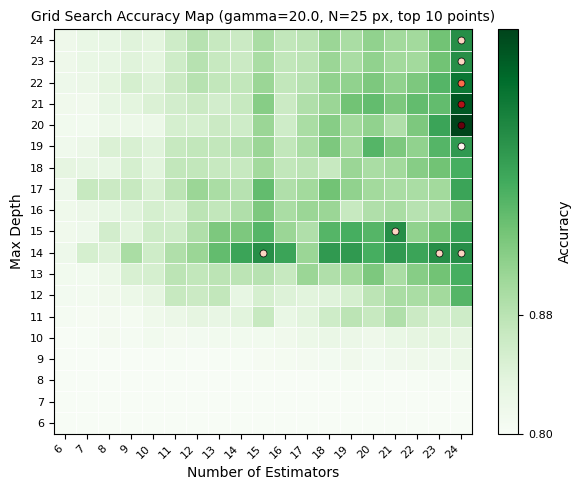

In [14]:
#  отображение результата перебора на тепловой карте
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle
from matplotlib.colors import PowerNorm

# Извлекаем результаты для карты
results = gs.cv_results_
max_depth_values = param_grid['randomforestclassifier__max_depth']
n_estimators_values = param_grid['randomforestclassifier__n_estimators']

# Создаем матрицу точности
accuracy_matrix = np.zeros((len(max_depth_values), len(n_estimators_values)))

for i, max_depth in enumerate(max_depth_values):
    for j, n_estimators in enumerate(n_estimators_values):
        idx = np.where((results['param_randomforestclassifier__max_depth'].data == max_depth) &
                       (results['param_randomforestclassifier__n_estimators'].data == n_estimators))[0][0]
        accuracy_matrix[i, j] = results['mean_test_score'][idx]

# Параметры отображения
N = 25  # размер квадратика в пикселях (чем больше, тем крупнее квадраты)
gamma = 20.0  # чем больше gamma, тем сильнее подавляются низкие значения (осветляются)
MAX_N = 10  # количество отображаемых точек максимума
MAX_S = 1  # размер точек максимума в пикселях

# Определяем размер квадрата в координатах графика
# Чем больше N, тем больше места занимает каждый квадрат
square_size = 0.5 + (N / 50)  # при N=20 -> size=0.9, при N=50 -> size=1.5

# Нормализуем значения точности для степенной шкалы (подавление низких значений)
vmin = np.min(accuracy_matrix)
vmax = np.max(accuracy_matrix)
norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

# Создаем график
fig, ax = plt.subplots(figsize=(6, 5))

# Рисуем квадратики
for i, depth in enumerate(max_depth_values):
    for j, estimators in enumerate(n_estimators_values):
        acc_value = accuracy_matrix[i, j]
        # Нормализуем значение для цветовой карты
        color_idx = norm(acc_value)
        color = plt.cm.Greens(color_idx)

        # Рисуем квадрат размером square_size
        rect = Rectangle((estimators - square_size/2, depth - square_size/2),
                         square_size, square_size,
                         facecolor=color, edgecolor='white', linewidth=0.5)
        ax.add_patch(rect)

# Находим TOP MAX_N точек максимума
all_accuracies = accuracy_matrix.flatten()
top_indices = np.argsort(all_accuracies)[-MAX_N:][::-1]
top_positions = [np.unravel_index(idx, accuracy_matrix.shape) for idx in top_indices]

# Нормализуем значения точности для цветовой шкалы (от темно-красного к светлому)
top_accuracies = [accuracy_matrix[i, j] for i, j in top_positions]
min_top_acc = min(top_accuracies)
max_top_acc = max(top_accuracies)

# Отмечаем TOP MAX_N точек с градиентом от темно-красного к светлому
for idx, (i, j) in enumerate(top_positions):
    acc_value = accuracy_matrix[i, j]
    depth_val = max_depth_values[i]
    estimators_val = n_estimators_values[j]

    # Нормализуем значение для цветовой карты красных оттенков
    if max_top_acc - min_top_acc > 0:
        color_norm = (acc_value - min_top_acc) / (max_top_acc - min_top_acc)
    else:
        color_norm = 0.5

    # Цвет от темно-красного (0) до светло-красного/розового (1)
    color = plt.cm.Reds(color_norm)

    # Размер точки максимума тоже зависит от N
    point_size = MAX_S * N
    ax.scatter(estimators_val, depth_val,
              s=point_size, marker='o', color=color,
              edgecolors='black', linewidth=0.5, zorder=5)

# Настройка осей
ax.set_xlabel('Number of Estimators', fontsize=10)
ax.set_ylabel('Max Depth', fontsize=10)
ax.set_title(f'Grid Search Accuracy Map (gamma={gamma}, N={N} px, top {MAX_N} points)', fontsize=10)

# Устанавливаем границы осей с учетом размера квадратов
margin = square_size / 2
ax.set_xlim(min(n_estimators_values) - margin, max(n_estimators_values) + margin)
ax.set_ylim(min(max_depth_values) - margin, max(max_depth_values) + margin)

# Настройка меток на осях
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8, integer=True))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, integer=True))

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)

# Добавляем цветовую легенду с степенной нормализацией
sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Accuracy', fontsize=10)
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
cbar.ax.tick_params(labelsize=8)

# Настройка сетки
ax.set_xticks(n_estimators_values)
ax.set_yticks(max_depth_values)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##optuna

In [15]:
!pip install optuna -q

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def objective(trial):
    """
    Целевая функция для Optuna.
    Trial - одна попытка подбора параметров
    """
    # Предлагаем параметры для подбора
    params = {
      'n_estimators'     : trial.suggest_int('n_estimators', 10, 100),                                 # default=100
      # 'criterion'        : trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),   # default='gini'
      'max_depth'        : trial.suggest_int('max_depth', 10, 30),                                    # default=None
      # 'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),                             # default=2
      # 'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),                              # default=1
      # 'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),         # default='sqrt'
      # max_leaf_nodes
      # min_impurity_decrease
      # ccp_alpha
      # 'max_samples'      : trial.suggest_float('max_samples', 0.5, 1.0),
    }

    # Устанавливаем параметры в пайплайн
    pipe_rf = make_pipeline(
        RandomForestClassifier(random_state=1, **params)
    )

    # Оцениваем качество через кросс-валидацию
    scores = cross_val_score(pipe_rf,
                             X_train, y_train,
                             cv=3,
                             scoring='accuracy',
                             n_jobs=2
    )

    # Возвращаем среднюю точность (чем выше, тем лучше)
    return scores.mean()

# Отключаем все логи Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # или ERROR, CRITICAL

# Создаем исследование
study = optuna.create_study(direction='maximize',               # максимизировать точность
                           sampler=optuna.samplers.TPESampler() # умный алгоритм подбора
)

# Запускаем поиск (всего 20 попыток)
study.optimize(objective,
               n_trials=200,
               show_progress_bar=True
)

# Получаем лучшие параметры
print('')
print_aligned_dict(study.best_params)

# Обучаем модель с лучшими параметрами на всех обучающих данных
pipe_rf = make_pipeline(
    RandomForestClassifier(random_state=1, **study.best_params)
)
pipe_rf.fit(X_train, y_train)

# Предсказания и метрики
y_pred = pipe_rf.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)
print('')

In [17]:
# 2. Визуализация результатов
optuna.visualization.plot_optimization_history(study)

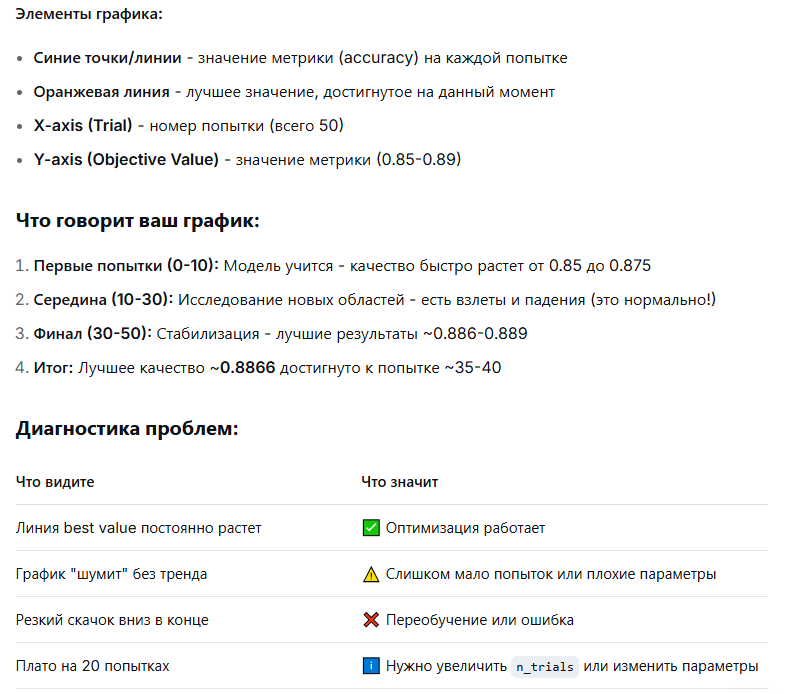

In [18]:
optuna.visualization.plot_parallel_coordinate(study)

In [19]:
# ✅ Способ 4: Процентный порог (топ X%)
# Берем топ 20% лучших попыток
percentile = 80  # топ 20% (80-й перцентиль и выше)

# Получаем все значения accuracy
values = [t.value for t in study.trials if t.value is not None]
threshold = np.percentile(values, percentile)

print(f"Порог для топ 20%: {threshold:.4f}")

# Фильтруем
filtered_study = optuna.create_study(direction='maximize')
for trial in study.trials:
    if trial.value is not None and trial.value >= threshold:
        filtered_study.add_trial(trial)

# Строим график
fig = optuna.visualization.plot_parallel_coordinate(
    filtered_study,
    # params=['max_depth', 'n_estimators']
)
fig.show()

print(f"Показано {len(filtered_study.trials)} попыток из {len(study.trials)}")

Порог для топ 20%: 0.8884


Показано 52 попыток из 200


In [20]:
fig = optuna.visualization.plot_slice(
    study,
    # params=['max_depth', 'max_features', 'min_samples_split', 'n_estimators']
)
fig.show()

In [21]:
fig = optuna.visualization.plot_contour(
    study,
    # params=['max_depth', 'max_features', 'n_estimators']
)
fig.show()

In [22]:
optuna.visualization.plot_rank(study)

In [23]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
import numpy as np

# Определяем несколько метрик
scoring = {
    'accuracy'  : 'accuracy',
    'f1'        : make_scorer(f1_score, average='weighted'),
    'recall'    : make_scorer(recall_score, average='weighted'),
    'precision' : make_scorer(precision_score, average='weighted')
}

pipe_rf = make_pipeline(
    RandomForestClassifier(n_estimators=42, # 10 20 40 20 18 15 42
                           max_depth=14,    # 12  9 14 22 14 14 14
                           random_state=1)  # 88 87 89 90 89 88 90
)
scores = cross_validate(estimator=pipe_rf,
                        X=X_train,
                        y=y_train,
                        cv=10,
                        scoring=scoring,
                        n_jobs=2)

# Выводим результаты
print('')
for metric_name in scores.keys():
    if metric_name.startswith('test_'):  # только метрики
        metric_scores = scores[metric_name]
        print(f'{metric_name[5:]:<10}(test): {np.mean(metric_scores):.2f} +/- {np.std(metric_scores):.3f}')


accuracy  (test): 0.90 +/- 0.024
f1        (test): 0.89 +/- 0.025
recall    (test): 0.90 +/- 0.024
precision (test): 0.90 +/- 0.025


##оценка max_depth при фиксированном n_estimators=20

In [ ]:
# оценка max_depth при фиксированном n_estimators=20
from sklearn.model_selection import validation_curve
param_range = range(1, 30)
train_scores, test_scores = validation_curve(
                estimator=pipe_rf,
                X=X_train,
                y=y_train,
                param_name='randomforestclassifier__max_depth',
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
# plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('randomforestclassifier__max_depth')
plt.ylabel('Accuracy')
plt.ylim([0.2, 1.0])
plt.tight_layout()
# plt.savefig('images/06_06.png', dpi=300)
plt.show()


##оценка n_estimators при фиксированном max_depth=22

In [ ]:
# оценка n_estimators при фиксированном max_depth=22
from sklearn.model_selection import validation_curve
param_range = range(1, 30)
train_scores, test_scores = validation_curve(
                estimator=pipe_rf,
                X=X_train,
                y=y_train,
                param_name='randomforestclassifier__n_estimators',
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
# plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('randomforestclassifier__n_estimators')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.tight_layout()
# plt.savefig('images/06_06.png', dpi=300)
plt.show()

In [ ]:
# переобучим с выбранными параметрами
pipe_rf = make_pipeline(
    RandomForestClassifier(n_estimators=20,
                           max_depth=22,
                           random_state=1)
)
pipe_rf.fit(X_train, y_train)
print_aligned_dict(pipe_rf.get_params())

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=pipe_rf.classes_))

##ROC кривая

In [ ]:
# ROC кривая
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Бинаризуем метки
y_test_bin = label_binarize(y_test, classes=pipe_rf.named_steps['randomforestclassifier'].classes_)
n_classes = y_test_bin.shape[1]

# Получаем вероятности
y_proba = pipe_rf.predict_proba(X_test)

# Вычисляем ROC для каждого класса
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average (глобальное усреднение)
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average (усреднение по классам)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# График
plt.figure(figsize=(8, 6))

# Две обобщенные кривые
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         color='blue', lw=2)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
         color='red', lw=2, linestyle='--')

# Диагональ (случайная модель)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves - Random Forest (Multiclass, {n_classes} classes)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Вывод статистики
print(f"=== ROC-AUC Summary ===")
print(f"Micro-average AUC: {roc_auc['micro']:.3f}")
print(f"Macro-average AUC: {roc_auc['macro']:.3f}")
print(f"Per-class AUC: min={min(roc_auc[i] for i in range(n_classes)):.3f}, "
      f"max={max(roc_auc[i] for i in range(n_classes)):.3f}, "
      f"mean={np.mean([roc_auc[i] for i in range(n_classes)]):.3f}")

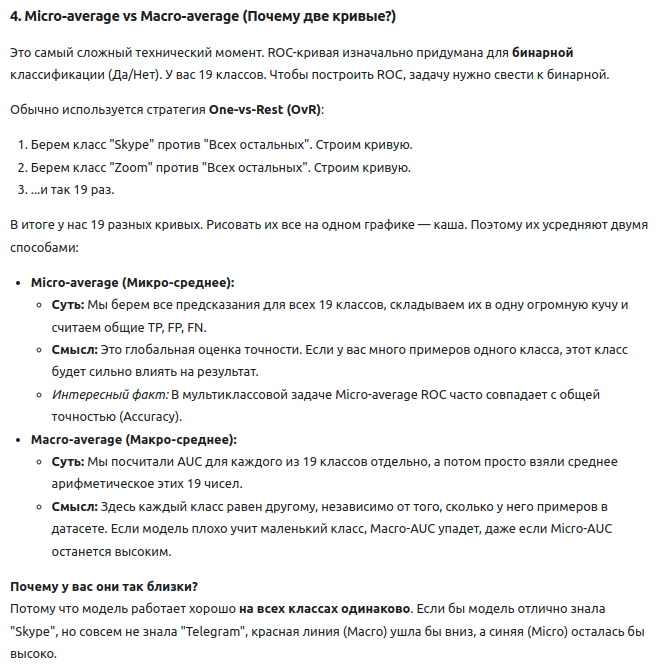

In [ ]:
# Тепловая карта AUC по классам
import seaborn as sns
import pandas as pd

# Собираем AUC по классам
auc_per_class = [(pipe_rf.classes_[i], roc_auc[i]) for i in range(n_classes)]
auc_df = pd.DataFrame(auc_per_class, columns=['Class', 'AUC'])
auc_df = auc_df.sort_values('AUC', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=auc_df, x='AUC', y='Class', palette='viridis')
plt.xlabel('AUC Score')
plt.title(f'ROC-AUC by Class (mean = {np.mean([a for _, a in auc_per_class]):.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##матрица ошибок

In [ ]:
# полная матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Предсказания
y_pred = pipe_rf.predict(X_test)

# Построение матрицы
cm = confusion_matrix(y_test, y_pred, labels=pipe_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe_rf.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Reds', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# матрица ошибок без диагональных элементов
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Предсказания
y_pred = pipe_rf.predict(X_test)

# Построение матрицы
cm = confusion_matrix(y_test, y_pred, labels=pipe_rf.classes_)

# Конвертируем в float (чтобы можно было использовать NaN)
cm = cm.astype(float)

# Очищаем диагональные элементы (делаем их NaN)
np.fill_diagonal(cm, np.nan)

# Создаем фигуру
fig, ax = plt.subplots(figsize=(8, 8))

# Отображаем матрицу
im = ax.imshow(cm, cmap='Reds', interpolation='nearest')

# Цветовая шкала
plt.colorbar(im, ax=ax)

# Подписи осей
ax.set_xticks(np.arange(len(pipe_rf.classes_)))
ax.set_yticks(np.arange(len(pipe_rf.classes_)))
ax.set_xticklabels(pipe_rf.classes_, rotation=90, ha='right')
ax.set_yticklabels(pipe_rf.classes_)

# Добавляем значения в ячейки (кроме диагонали)
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and not np.isnan(cm[i, j]):
            text = ax.text(j, i, int(cm[i, j]),
                          ha="center", va="center",
                          color="white" if cm[i, j] > np.nanmax(cm)/2 else "black")

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix (Diagonal Empty)')

plt.tight_layout()
plt.show()

##PR кривая

In [ ]:
# обощенная PR кривая
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 1. Подготовка данных
y_test_bin = label_binarize(y_test, classes=pipe_rf.classes_)
n_classes = y_test_bin.shape[1]
y_proba = pipe_rf.predict_proba(X_test)

precision = dict()
recall = dict()
average_precision = dict()

# 2. Вычисляем PR-метрики для каждого класса
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_proba[:, i])

# 3. Micro-average (глобальное усреднение)
precision["micro"], recall["micro"], thresholds_micro = precision_recall_curve(y_test_bin.ravel(), y_proba.ravel())
average_precision["micro"] = average_precision_score(y_test_bin, y_proba, average="micro")

# 4. Macro-average (усреднение по классам с интерполяцией)
all_recall = np.linspace(0, 1, 100)
mean_precision = np.zeros_like(all_recall)
for i in range(n_classes):
    mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])
mean_precision /= n_classes
precision["macro"] = mean_precision
recall["macro"] = all_recall
average_precision["macro"] = average_precision_score(y_test_bin, y_proba, average="macro")

# 5. Построение графика
plt.figure(figsize=(10, 8))

# Индивидуальные кривые
for i in range(n_classes):
    plt.plot(recall[i], precision[i], color='gray', alpha=0.15, lw=1)

# Обобщенные кривые
plt.plot(recall["micro"], precision["micro"],
         label=f'Micro-average AP = {average_precision["micro"]:.3f}',
         color='blue', lw=2)

plt.plot(recall["macro"], precision["macro"],
         label=f'Macro-average AP = {average_precision["macro"]:.3f}',
         color='red', lw=2, linestyle='--')

# --- ИЗМЕНЕНИЕ: Рисуем точки для разных порогов ---
thresholds_to_mark = [0.3, 0.5, 0.7]

for t_val in thresholds_to_mark:
    # Находим ближайший порог
    idx = np.argmin(np.abs(thresholds_micro - t_val))

    p_at_t = precision["micro"][idx]
    r_at_t = recall["micro"][idx]
    real_threshold = thresholds_micro[idx]

    # Настройки для точек
    if t_val == 0.5:
        color = 'red'
        size = 60       # Уменьшили размер с 150 до 60
        z_order = 6     # Поверх остальных точек
        label = f'Threshold 0.5'
    else:
        color = 'green'  # ИЗМЕНЕНО: было 'gray', стало 'green'
        size = 40       # Меньше для вспомогательных точек
        z_order = 5
        label = f'Threshold {t_val}'

    # Рисуем точку
    plt.scatter([r_at_t], [p_at_t], color=color, s=size, zorder=z_order, label=label)

    # Подпись координат рядом с точкой
      # Подпись порога рядом с точкой
    plt.annotate(f'Threshold = {t_val}',
                 xy=(r_at_t, p_at_t), xytext=(r_at_t + 0.02, p_at_t),
                 fontsize=9, color=color, alpha=0.8, va='center')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Random Forest (Multiclass, 19 classes)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

# Вывод статистики
print(f"=== Precision-Recall Summary ===")
print(f"Micro-average AP: {average_precision['micro']:.3f}")
print(f"Macro-average AP: {average_precision['macro']:.3f}")

# Вывод координат для отмеченных порогов
for t_val in thresholds_to_mark:
    idx = np.argmin(np.abs(thresholds_micro - t_val))
    print(f"Threshold ~{t_val}: P={precision['micro'][idx]:.3f}, R={recall['micro'][idx]:.3f}")

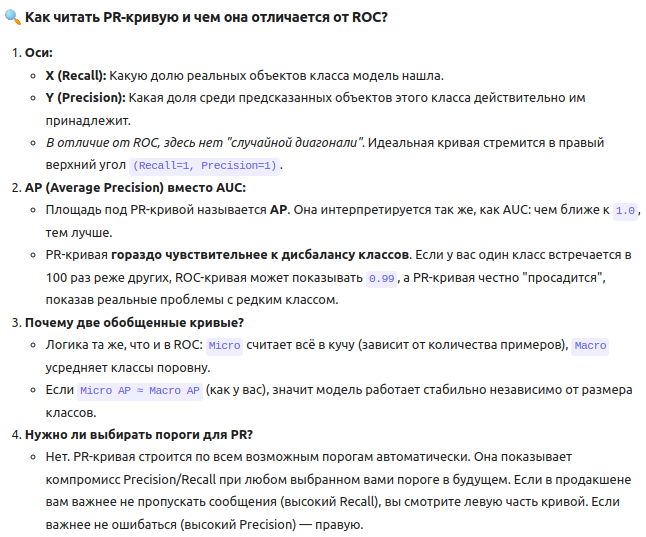

In [ ]:
# детализированная PR кривая
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from matplotlib.lines import Line2D  # Импортируем для создания кастомных элементов легенды

# 1. Подготовка данных
y_test_bin = label_binarize(y_test, classes=pipe_rf.classes_)
n_classes = y_test_bin.shape[1]
y_proba = pipe_rf.predict_proba(X_test)

precision = dict()
recall = dict()
average_precision = dict()

# 2. Вычисляем метрики для каждого класса
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_proba[:, i])

# 3. Micro-average
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_proba.ravel())
average_precision["micro"] = average_precision_score(y_test_bin, y_proba, average="micro")

# 4. Macro-average
all_recall = np.linspace(0, 1, 100)
mean_precision = np.zeros_like(all_recall)
for i in range(n_classes):
    mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])
mean_precision /= n_classes
precision["macro"] = mean_precision
recall["macro"] = all_recall
average_precision["macro"] = average_precision_score(y_test_bin, y_proba, average="macro")

# === НАСТРОЙКИ СТИЛЕЙ ===
linestyles = ['-', '--', '-.', ':']
# Наборы маркеров (будут циклически повторяться)
markers = ['o', 's', 'D', '^', 'v', 'p', 'h', 'H', '*']
colors = plt.cm.viridis(np.linspace(0, 1, n_classes))

fig, ax = plt.subplots(figsize=(14, 10))

# Список для хранения элементов легенды
custom_legend_elements = []

# 5. Рисуем классы
for i in range(n_classes):
    # Выбираем стиль и маркер по индексу
    style = linestyles[i % len(linestyles)]
    marker = markers[i % len(markers)]

    # --- Отрисовка на графике ---

    # Линия
    ax.plot(recall[i], precision[i],
            color=colors[i], linestyle=style, lw=2, alpha=0.8)

    # Маркеры (рисуем отдельно, чтобы задать markevery)
    ax.plot(recall[i], precision[i],
            color=colors[i], linestyle='', marker=marker,
            markevery=10, markersize=6, markerfacecolor=colors[i],
            markeredgecolor='black', alpha=0.9)

    # --- Создание иконки для легенды ---
    custom_legend_elements.append(
        Line2D([0], [0], color=colors[i], linestyle=style, marker=marker,
               lw=2, markerfacecolor=colors[i], markeredgecolor='black',
               markersize=6, markevery=5,  # markevery для легенды (чтобы не было сплошной линии маркеров)
               label=pipe_rf.classes_[i])
    )

# 6. Рисуем Micro и Macro кривые поверх всех
ax.plot(recall["micro"], precision["micro"], color='blue', lw=3, linestyle='-')
ax.plot(recall["macro"], precision["macro"], color='red', lw=3, linestyle='--')

# Добавляем Micro/Macro в список элементов легенды
custom_legend_elements.append(Line2D([0], [0], color='blue', lw=3, linestyle='-',
                                     label=f'Micro-average (AP={average_precision["micro"]:.3f})'))
custom_legend_elements.append(Line2D([0], [0], color='red', lw=3, linestyle='--',
                                     label=f'Macro-average (AP={average_precision["macro"]:.3f})'))

# 7. Финальные настройки графика
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (19 Classes)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Выводим легенду: ncol=1 (в одну колонку), markerscale=2.0 (увеличиваем иконки)
ax.legend(handles=custom_legend_elements,
          loc='center left', bbox_to_anchor=(1.02, 0.5),
          ncol=1, fontsize='medium', markerscale=2.0, handlelength=6.0)

plt.tight_layout()
plt.show()

# Вывод статистики
print(f"=== Precision-Recall Summary ===")
print(f"Micro-average AP: {average_precision['micro']:.3f}")
print(f"Macro-average AP: {average_precision['macro']:.3f}")

In [ ]:
# В мультиклассовой задаче метод .predict() вообще не использует пороги. Он просто берёт класс с максимальной вероятностью (argmax), даже если эта вероятность равна 30%.
# Чтобы применить порог, вам нужно заменить одну строчку y_pred = pipe_rf.predict(X_test) на блок работы с вероятностями. Вот готовый фрагмент, который вставляется прямо вместо вашей последней строки:
# import numpy as np

# # 1. Получаем вероятности вместо готовых предсказаний
# y_proba = pipe_rf.predict_proba(X_test)

# # === МЕНЯЙТЕ ПОРОГ ЗДЕСЬ ===
# CUSTOM_THRESHOLD = 0.6

# # 2. Находим индекс лучшего класса и его вероятность для каждого примера
# best_class_idx = np.argmax(y_proba, axis=1)
# best_class_prob = np.max(y_proba, axis=1)

# # 3. Применяем порог: если уверенность ниже порога → "Unknown"
# y_pred_custom = np.array([
#     pipe_rf.classes_[idx] if prob >= CUSTOM_THRESHOLD else "Unknown"
#     for idx, prob in zip(best_class_idx, best_class_prob)
# ])

# # Теперь y_pred_custom можно использовать вместо y_pred



# Так как появился класс "Unknown", обычная accuracy_score сломается. Считайте точность только по тем примерам, где модель всё-таки рискнула предсказать:
# from sklearn.metrics import accuracy_score, classification_report

# # Оставляем только примеры, где модель сделала предсказание (не Unknown)
# mask = y_pred_custom != "Unknown"
# y_test_filtered = y_test[mask]
# y_pred_filtered = y_pred_custom[mask]

# print(f"Сделано предсказаний: {np.sum(mask)} из {len(y_test)}")
# print(f"Accuracy (с порогом {CUSTOM_THRESHOLD}): {accuracy_score(y_test_filtered, y_pred_filtered):.3f}")
# print("\nClassification Report:")
# print(classification_report(y_test_filtered, y_pred_filtered))

##Накопленная значимость признаков

In [ ]:
# Накопленная значимость признаков для CatBoost
importances = pipe_rf.named_steps['randomforestclassifier'].feature_importances_
indices = np.argsort(importances)[::-1]

sorted_importances = importances[indices]
# Нормируем важности, чтобы их сумма была равна 1
sorted_importances = sorted_importances / sorted_importances.sum()
cumulative_importances = np.cumsum(sorted_importances)

# График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Отдельные важности
ax1.bar(range(len(importances)), sorted_importances, align='center', color='steelblue')
ax1.set_xlabel('Feature Index')
ax1.set_ylabel('Importance')
ax1.set_title('Individual Feature Importance')

# Накопленная важность
ax2.plot(range(1, len(importances) + 1), cumulative_importances, 'bo-', linewidth=2)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Находим сколько признаков нужно для 95% важности
n_for_95 = np.where(cumulative_importances >= 0.95)[0][0] + 1
print(f"Для достижения 95% важности нужно {n_for_95} признаков")

plt.tight_layout()
plt.show()

In [ ]:
# построить диаграмму занчимости признаков
importances = pipe_rf.named_steps['randomforestclassifier'].feature_importances_
indices = np.argsort(importances)[::-1]
feat_labels = df.columns[1:]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (
        f + 1,
        30,
        feat_labels[indices[f]],
        importances[indices[f]])
    )

# plt.t('Feature Importance')
plt.bar(range(X_train.shape[1]),
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
#plt.savefig('images/04_09.png', dpi=300)
plt.show()

##Проверка модели

In [ ]:
# проверка модели
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib
import os

#
# ============== ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ ==============
print("\n" + "="*50)
print("ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*50)

forest = pipe_rf.named_steps['randomforestclassifier']
y_pred = forest.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nДетальный отчет по классам:")
print(classification_report(y_test, y_pred, zero_division=0))

# ============== СОХРАНЕНИЕ МОДЕЛИ ==============
print("\n" + "="*50)
print("СОХРАНЕНИЕ МОДЕЛИ")
print("="*50)

# Сохраняем модель
model_filename = 'random_forest_model.pkl'
joblib.dump(forest, model_filename)
print(f"✓ Модель сохранена в файл: {model_filename}")

# Сохраняем список признаков (для проверки при загрузке)
feature_file = 'model_features.txt'
with open(feature_file, 'w', encoding='utf-8') as f:
    for feature in feat_labels:
        f.write(feature + '\n')
print(f"✓ Список признаков сохранен в: {feature_file}")

# Сохраняем метаданные модели (классы и т.д.)
model_info = {
    'n_features': X_train.shape[1],
    'feature_names': list(feat_labels),  # 👈 ПРЕОБРАЗУЕМ В СПИСОК
    'classes': forest.classes_.tolist(),
    'n_estimators': forest.n_estimators,
    'test_accuracy': float(accuracy),    # 👈 ПРЕОБРАЗУЕМ В float (на всякий случай)
    'test_f1': float(f1)                 # 👈 ПРЕОБРАЗУЕМ В float
}

import json
with open('model_info.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)
print(f"✓ Метаданные модели сохранены в: model_info.json")

# ============== ЗАГРУЗКА МОДЕЛИ ==============
print("\n" + "="*50)
print("ЗАГРУЗКА МОДЕЛИ ИЗ ФАЙЛА")
print("="*50)

if os.path.exists(model_filename):
    loaded_model = joblib.load(model_filename)
    print(f"✓ Модель загружена из файла: {model_filename}")

    # Проверяем, что модель загрузилась корректно
    print(f"  Тип модели: {type(loaded_model).__name__}")
    print(f"  Количество деревьев: {loaded_model.n_estimators}")
    print(f"  Количество классов: {len(loaded_model.classes_)}")

    # Загружаем список признаков
    if os.path.exists(feature_file):
        with open(feature_file, 'r', encoding='utf-8') as f:
            loaded_features = [line.strip() for line in f.readlines()]
        print(f"✓ Загружен список признаков ({len(loaded_features)} признаков)")

        # Проверяем соответствие
        if len(loaded_features) == X_test.shape[1]:
            print("  ✓ Количество признаков совпадает с тестовыми данными")
        else:
            print(f"  ⚠ Внимание: количество признаков не совпадает! Ожидалось: {X_test.shape[1]}, получено: {len(loaded_features)}")
else:
    print(f"✗ Ошибка: файл {model_filename} не найден!")

# ============== ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ ==============
print("\n" + "="*50)
print("ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ")
print("="*50)

# Делаем предсказания загруженной моделью
y_pred_loaded = loaded_model.predict(X_test)

# Сравниваем с оригинальной моделью
if np.array_equal(y_pred, y_pred_loaded):
    print("✓ Предсказания загруженной модели совпадают с оригинальной!")
else:
    print("✗ Предсказания отличаются! Что-то пошло не так.")

# Метрики загруженной модели
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
precision_loaded = precision_score(y_test, y_pred_loaded, average='weighted', zero_division=0)
recall_loaded = recall_score(y_test, y_pred_loaded, average='weighted', zero_division=0)
f1_loaded = f1_score(y_test, y_pred_loaded, average='weighted', zero_division=0)

print("\nМетрики загруженной модели на тестовых данных:")
print(f"Accuracy:  {accuracy_loaded:.4f}")
print(f"Precision: {precision_loaded:.4f}")
print(f"Recall:    {recall_loaded:.4f}")
print(f"F1-score:  {f1_loaded:.4f}")

# ============== СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ==============
print("\n" + "="*50)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*50)

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'true_value': y_test,
    'predicted': y_pred,
    'correct': y_test == y_pred
})

# Добавляем информацию об ошибках
results_df['error_type'] = results_df.apply(
    lambda row: 'correct' if row['correct'] else f"{row['true_value']} → {row['predicted']}",
    axis=1
)

# Сохраняем результаты
results_file = 'test_predictions.csv'
results_df.to_csv(results_file, sep=';', index=False)
print(f"✓ Результаты предсказаний сохранены в: {results_file}")

# Сохраняем метрики в отдельный файл
metrics_df = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall', 'f1_score'],
    'value': [accuracy, precision, recall, f1]
})
metrics_file = 'test_metrics.csv'
metrics_df.to_csv(metrics_file, sep=';', index=False)
print(f"✓ Метрики сохранены в: {metrics_file}")

# ============== ИТОГ ==============
print("\n" + "="*50)
print("ИТОГ")
print("="*50)
print(f"✓ Модель обучена и сохранена в {model_filename}")
print(f"✓ Метрики на тестовых данных: Accuracy={accuracy:.4f}, F1={f1:.4f}")
print(f"✓ Загруженная модель успешно протестирована")
print("✓ Все результаты сохранены в файлы")

# CatBoost

In [ ]:
!pip install catboost -q
import catboost
print(catboost.__version__)

In [ ]:
# Основные параметры:
# iterations (или n_estimators) - количество деревьев в ансамбле
#   Чем больше, тем сложнее модель, но растет риск переобучения
#   Обычно 100-1000, но можно использовать раннюю остановку

# learning_rate - скорость обучения
#   Уменьшает вклад каждого нового дерева (обычно 0.01-0.3)
#   Меньшее значение требует больше деревьев, но часто дает лучшее качество

# depth - максимальная глубина деревьев
#   Аналог max_depth в Random Forest
#   Обычно 4-10, редко больше (CatBoost по умолчанию использует симметричные деревья)

# loss_function - функция потерь
#   'MultiClass' - для многоклассовой классификации
#   'Logloss' - для бинарной классификации

# eval_metric - метрика для контроля качества
#   'Accuracy', 'F1', 'Precision', 'Recall'
#   Используется для ранней остановки и отбора лучших итераций

# early_stopping_rounds - ранняя остановка

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score


# Разделяем на обучающую и валидационную выборки
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Создаем модель CatBoost
catboost_model = CatBoostClassifier(
    iterations=500,           # Количество деревьев (аналог n_estimators)
    early_stopping_rounds=50, # Остановиться, если за 20 итераций нет улучшений
    learning_rate=0.1,        # Скорость обучения (шаг градиентного спуска)
    depth=3,                  # Глубина деревьев (аналог max_depth)
    random_seed=42,           # Фиксация случайности для воспроизводимости
    loss_function='MultiClass',  # Функция потерь для многоклассовой классификации
    eval_metric='Accuracy',   # Метрика для оценки на валидации
    l2_leaf_reg=5,            # Регуляризация (по умолчанию 3)
    # verbose=10,               # Печатать результат каждые 10 итераций
)

# Обучаем модель
# catboost_model.fit(X_train, y_train)
# catboost_model.fit(X_train, y_train, eval_set=(X_val, y_val))
# catboost_model.fit(X_train, y_train, cat_features=[0, 2, 5])  # Индексы категориальных колонок

# Обучаем с валидацией (CatBoost автоматически использует раннюю остановку)
catboost_model.fit(
    X_train_part, y_train_part,
    eval_set=(X_val, y_val),
    verbose=50,                # Печатать результат каждые 10 итераций
    plot=False                 # Поставьте True, если хотите график в Jupyter
)

# Предсказания
y_pred = catboost_model.predict(X_test)

# Оценка качества
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))

# Лучшее количество итераций (деревьев)
print(f"Оптимальное количество деревьев: {catboost_model.get_best_iteration()}")

In [ ]:
# построить диаграмму значимости признаков для CatBoost
importances = catboost_model.get_feature_importance()
indices = np.argsort(importances)[::-1]
# Используем названия признаков из df (как в исходном коде)
feat_labels = df.columns[1:]  # как было в оригинале

# Вывод важности признаков в консоль
for f in range(len(feat_labels)):
    print("%2d) %-*s %f" % (
        f + 1,
        30,
        feat_labels[indices[f]],
        importances[indices[f]])
    )

# Построение графика важности признаков
plt.figure(figsize=(10, 6))
plt.bar(range(len(feat_labels)), importances[indices], align='center')

plt.xticks(range(len(feat_labels)), feat_labels[indices], rotation=90)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков (CatBoost)')
plt.xlim([-1, len(feat_labels)])
plt.tight_layout()
plt.show()

In [ ]:
# Накопленная значимость признаков для CatBoost
importances = catboost_model.get_feature_importance()
indices = np.argsort(importances)[::-1]

sorted_importances = importances[indices]
# Нормируем важности, чтобы их сумма была равна 1
sorted_importances = sorted_importances / sorted_importances.sum()
cumulative_importances = np.cumsum(sorted_importances)

# График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Отдельные важности
ax1.bar(range(len(importances)), sorted_importances, align='center', color='steelblue')
ax1.set_xlabel('Feature Index')
ax1.set_ylabel('Importance')
ax1.set_title('Individual Feature Importance')

# Накопленная важность
ax2.plot(range(1, len(importances) + 1), cumulative_importances, 'bo-', linewidth=2)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Находим сколько признаков нужно для 95% важности
n_for_95 = np.where(cumulative_importances >= 0.95)[0][0] + 1
print(f"Для достижения 95% важности нужно {n_for_95} признаков")

plt.tight_layout()
plt.show()

In [ ]:
# # Можно получить разные типы важности признаков
# # PredictedValuesChange - влияние на изменение предсказаний (по умолчанию)
# # LossFunctionChange - влияние на функцию потерь
# # ShapValues - значения SHAP

# importances_shap = catboost_model.get_feature_importance(type='ShapValues')
# importances_loss = catboost_model.get_feature_importance(type='LossFunctionChange')

# # Для визуализации можно также использовать встроенный метод
# catboost_model.get_feature_importance(data=X_train,
#                                        type='PredictionValuesChange',
#                                        prettified=True)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'l2_leaf_reg': [0, 3, 6]

    # 'depth': [2, 4, 6, 8, 10, 12],
    # 'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
    # 'l2_leaf_reg': [0, 1, 2, 3, 5, 7, 9]
}

catboost_model = CatBoostClassifier(
    iterations=200,           # Количество деревьев (аналог n_estimators)
    random_seed=42,           # Фиксация случайности для воспроизводимости
    loss_function='MultiClass',  # Функция потерь для многоклассовой классификации
    thread_count=-1,
    logging_level='Silent',  # 🤫 Глушим логи CatBoost
)

grid = GridSearchCV(
    catboost_model,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    refit=True,               # финальное обучение
    verbose=3
)

grid.fit(
    X_train, y_train,
    verbose=50,                # Печатать результат каждые 10 итераций
    plot=False
)
# Лучшая модель, Предсказания на тестовой выборке
y_pred = grid.best_estimator_.predict(X_test)

# Оценка качества
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))
print_aligned_dict(grid.best_params_)

In [ ]:
import json
import os

# 2️⃣ Финальное обучение лучшей модели с early stopping
final_model = CatBoostClassifier(
    iterations=500,           # Количество деревьев (аналог n_estimators)
    early_stopping_rounds=50, # Остановиться, если за 20 итераций нет улучшений
    **grid.best_params_,
    random_seed=42,
    loss_function='MultiClass',
    eval_metric='Accuracy',
)

# Обучаем с валидацией (CatBoost автоматически использует раннюю остановку)
final_model.fit(
    X_train_part, y_train_part,
    eval_set=(X_val, y_val),
    verbose=50,                # Печатать результат каждые 10 итераций
    plot=False                 # Поставьте True, если хотите график в Jupyter
)

# 3️⃣ Оценка на тестовой выборке (которую модель не видела НИКОГДА)
y_pred = final_model.predict(X_test)
# Оценка качества
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))

# 1. Сохраняем модель в стандартном формате CatBoost
# ✅ Все деревья и их веса
# ✅ Параметры модели (depth, learning_rate, iterations и т.д.)
# ✅ Feature names (если были)
# ✅ Целевая метрика (eval_metric)
# ✅ Внутреннее состояние модели
# ✅ Нормализацию данных (если была)
final_model.save_model('/content/catboost_info/catboost_model.cbm')
# 2. Сохраняем также в формате Python (для обратной совместимости)
# final_model.save_model('/content/catboost_info/catboost_model.pkl', format='pickle')
import pickle
# Сохранение через pickle
with open('/content/catboost_info/catboost_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# 3. Сохраняем мета-информацию (параметры, метрики и т.д.)
model_info = {
    'model_type': 'CatBoostClassifier',
    'iterations': final_model.get_param('iterations'),
    'depth': final_model.get_param('depth'),
    'learning_rate': final_model.get_param('learning_rate'),
    'best_iteration': final_model.get_best_iteration(),
    'feature_names': list(X_train.columns) if hasattr(X_train, 'columns') else None
}

with open('/content/catboost_info/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

In [ ]:
import matplotlib.pyplot as plt

# Получаем историю обучения
evals_result = final_model.get_evals_result()

# График качества на валидации
plt.figure(figsize=(10, 6))
plt.plot(evals_result['validation']['Accuracy'], label='Validation Accuracy')
plt.axvline(x=final_model.get_best_iteration(), color='red', linestyle='--',
            label=f'Best iteration: {final_model.get_best_iteration()}')
plt.xlabel('Iteration (number of trees)')
plt.ylabel('Accuracy')
plt.title('Процесс обучения с early stopping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Способ 1: Загрузка из .cbm файла (рекомендуется)
loaded_model_cbm = CatBoostClassifier()
loaded_model_cbm.load_model('/content/catboost_info/catboost_model.cbm')

# Способ 2: Загрузка из pickle (если нужно)
# Загрузка через pickle
with open('/content/catboost_info/catboost_model.pkl', 'rb') as f:
    loaded_model_pickle = pickle.load(f)

y_pred = loaded_model_cbm.predict(X_test)
# Оценка качества
print('Accuracy(test cbm):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test cbm):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test cbm): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test cbm):        %.2f' % f1_score(y_test, y_pred, average='weighted'))
print('')

y_pred = loaded_model_pickle.predict(X_test)
# Оценка качества
print('Accuracy(test pkl):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test pkl):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test pkl): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test pkl):        %.2f' % f1_score(y_test, y_pred, average='weighted'))
print('')

# Дополнительно: можно вывести метрики по каждому классу
if hasattr(y_test, 'unique') and len(y_test.unique()) <= 10:
    print("\n" + "="*60)
    print("МЕТРИКИ ПО КАЖДОМУ КЛАССУ")
    print("="*60)
    print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*50)

    for class_label in sorted(y_test.unique()):
        # Создаем бинарные метки для текущего класса
        y_test_binary = (y_test == class_label).astype(int)
        y_pred_binary = (y_pred == class_label).astype(int)

        p = precision_score(y_test_binary, y_pred_binary, zero_division=0)
        r = recall_score(y_test_binary, y_pred_binary, zero_division=0)
        f = f1_score(y_test_binary, y_pred_binary, zero_division=0)

        print(f"{class_label:<10} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

# Загружаем мета-информацию (опционально)
if os.path.exists('/content/catboost_info/model_info.json'):
    with open('/content/catboost_info/model_info.json', 'r') as f:
        loaded_info = json.load(f)
    print(f"\n📋 Информация о модели:")
    print(f"   - Тип: {loaded_info['model_type']}")
    print(f"   - Количество деревьев: {loaded_info['iterations']}")
    print(f"   - Глубина: {loaded_info['depth']}")
    print(f"   - Лучшая итерация: {loaded_info['best_iteration']}")
    print('')

    import json
    print(json.dumps(loaded_info, indent=4, ensure_ascii=False))


#LightGBM

In [ ]:
# !pip install lightgbm -q
# !pip install lightgbm --install-option=--gpu
import lightgbm as lgb
print(f"LightGBM version: {lgb.__version__}")
# Проверка GPU (если устанавливали GPU версию)
# print(f"GPU enabled: {lgb.build_info().get('GPU_ENABLED', False)}")

##результат с одним фиксированным вариантом разбиения выборок

In [ ]:
# Основные параметры LightGBM:
# n_estimators - количество деревьев в ансамбле
#   Чем больше, тем сложнее модель, но растет риск переобучения
#   Обычно 100-1000, но можно использовать раннюю остановку

# learning_rate - скорость обучения
#   Уменьшает вклад каждого нового дерева (обычно 0.01-0.3)
#   Меньшее значение требует больше деревьев, но часто дает лучшее качество

# max_depth - максимальная глубина деревьев
#   Ограничивает глубину дерева (по умолчанию -1, что означает без ограничения)
#   Обычно 4-10, помогает контролировать переобучение

# num_leaves - количество листьев в дереве
#   Главный параметр для контроля сложности в LightGBM
#   По умолчанию 31, обычно меньше 2^max_depth
#   Меньшие значения уменьшают переобучение
#   (у CatBoost - depth)

# subsample - доля выборки для обучения каждого дерева (bagging)
#   Помогает бороться с переобучением, обычно 0.5-0.9

# colsample_bytree - доля признаков для обучения каждого дерева
#   Помогает бороться с переобучением, обычно 0.5-0.9

# reg_alpha и reg_lambda - L1 и L2 регуляризация
#   Помогают контролировать сложность модели

# min_child_samples - минимальное количество объектов в листе
#   Защищает от слишком глубоких веток

import lightgbm as lgb
# from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split

# Разделяем на обучающую и валидационную выборки
# Преобразовать X_train и X_test в numpy массивы в самом начале
X_train = X_train.values if hasattr(X_train, 'values') else X_train
X_test = X_test.values if hasattr(X_test, 'values') else X_test
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Создаем модель LightGBM
lightgbm_model = lgb.LGBMClassifier(
    n_estimators=500,          # Количество деревьев (аналог iterations)
    learning_rate=0.2,         # Скорость обучения (шаг градиентного спуска)
    max_depth=4,               # Максимальная глубина деревьев
    num_leaves=10,              # Количество листьев (обычно 2^max_depth, но можно меньше)
    subsample=0.8,             # Доля выборки для обучения каждого дерева
    colsample_bytree=0.8,      # Доля признаков для каждого дерева
    reg_alpha=0.1,             # L1 регуляризация
    reg_lambda=0.1,            # L2 регуляризация
    min_child_samples=20,      # Минимальное количество объектов в листе
    random_state=42,           # Фиксация случайности для воспроизводимости
    n_jobs=-1,                 # Использовать все ядра процессора
    verbose=-1,                # Отключаем вывод (можно поставить 0 или 1 для вывода)
)

# Обучаем модель с валидацией и ранней остановкой
lightgbm_model.fit(
    X_train_part, y_train_part,
    eval_set=(X_val, y_val),           # Валидационная выборка
    eval_metric='multi_logloss',       # Метрика для ранней остановки
    callbacks=[                        # Колбэки для контроля обучения
        lgb.early_stopping(stopping_rounds=50),  # Ранняя остановка
        lgb.log_evaluation(period=50)            # Вывод каждые 50 итераций
    ],
    # categorical_feature=[0, 2, 5],  # Индексы категориальных колонок
)

# Предсказания
y_pred = lightgbm_model.predict(X_test)

# Оценка качества
print('')
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))

# Лучшее количество итераций (деревьев)
print(f"Оптимальное количество деревьев: {lightgbm_model.best_iteration_}\n")

# Если нужно получить вероятности для каждого класса
# y_pred_proba = lightgbm_model.predict_proba(X_test)

##диаграммa значимости признаков

In [ ]:
# построить диаграмму значимости признаков для LightGBM
importances = lightgbm_model.feature_importances_
indices = np.argsort(importances)[::-1]
feat_labels = df.columns[1:]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (
        f + 1,
        30,
        feat_labels[indices[f]],
        importances[indices[f]])
    )

# plt.t('Feature Importance')
plt.bar(range(X_train.shape[1]),
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
#plt.savefig('images/04_09.png', dpi=300)
plt.show()

In [ ]:
# Накопленная значимость признаков для LightGBM
importances = lightgbm_model.feature_importances_
indices = np.argsort(importances)[::-1]

sorted_importances = importances[indices]
# Нормируем важности, чтобы их сумма была равна 1
sorted_importances = sorted_importances / sorted_importances.sum()
cumulative_importances = np.cumsum(sorted_importances)

# График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Отдельные важности
ax1.bar(range(len(importances)), sorted_importances, align='center', color='steelblue')
ax1.set_xlabel('Feature Index')
ax1.set_ylabel('Importance')
ax1.set_title('Individual Feature Importance')

# Накопленная важность
ax2.plot(range(1, len(importances) + 1), cumulative_importances, 'bo-', linewidth=2)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Находим сколько признаков нужно для 95% важности
n_for_95 = np.where(cumulative_importances >= 0.95)[0][0] + 1
print(f"Для достижения 95% важности нужно {n_for_95} признаков")

plt.tight_layout()
plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

##GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV

#        num_leaves: 38
#         max_depth: 8
#     learning_rate: 0.21
#      n_estimators: 60
# min_child_samples: 41
#         subsample: 0.93
#  colsample_bytree: 0.64
param_grid = {
    'num_leaves'   : [10, 20, 30, 40],  # Количество листьев в дереве
    'max_depth'    : [4, 6, 10],        # Максимальная глубина дерева
    'learning_rate': [0.05, 0.1, 0.15], # Скорость обучения
    'n_estimators' : [10, 20, 30]
}

# Базовые параметры модели
# Важно: n_estimators фиксирован, learning_rate будет меняться через param_grid
lightgbm_model = lgb.LGBMClassifier(
    n_estimators=200,        # Количество деревьев (фиксировано для подбора)
    random_state=42,         # Фиксация случайности
    verbose=-1,              # Отключаем вывод LightGBM
    n_jobs=-1                # Используем все ядра CPU
)

# GridSearchCV
grid = GridSearchCV(
    lightgbm_model,
    param_grid,
    cv=3,                    # 3-кратная кросс-валидация
    scoring='accuracy',      # Метрика для оценки
    n_jobs=1,               # Параллелизация поиска (можно -1 для всех ядер)
    refit=True,              # Переобучить на всех данных после поиска
    verbose=2                # Уровень детализации вывода
)
grid.fit(X_train, y_train)

# Лучшая модель, Предсказания на тестовой выборке
y_pred = grid.best_estimator_.predict(X_test)

# Оценка качества
print('\nРезультаты на тестовой выборке:')
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))

# Дополнительная информация
print(f"\nЛучшая accuracy на кросс-валидации: {grid.best_score_:.4f}")
print(f"Всего комбинаций параметров: {grid.n_splits_}\n")
# Лучшие параметры
print_aligned_dict(grid.best_params_)
grid_study = grid

In [ ]:
grid_study_best_params = grid.best_params_

##optuna

In [ ]:
!pip install optuna -q
!pip install optuna-integration[lightgbm] -q
!pip install optuna-dashboard -q

In [ ]:
# с прерыванием
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score  # ← ДОБАВИТЬ f1, recall, precision
import numpy as np

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Приводим к единообразию (ДОБАВИТЬ)
X_train_processed = X_train
X_test_processed = X_test
y_train_processed = y_train_enc
y_test_processed = y_test_enc

def objective(trial):
    params = {
        # https://lightgbm.readthedocs.io/en/v3.3.5/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier
        'num_leaves'        : trial.suggest_int('num_leaves', 2, 14),            # default=31
        'max_depth'         : trial.suggest_int('max_depth', 2, 10),             # default=-1
        'learning_rate'     : trial.suggest_float('learning_rate', 0.05, 0.3),   # default=0.1
        'n_estimators'      : trial.suggest_int('n_estimators', 10, 200),        # default=100
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 50),     # default=20
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),        # default=1.
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0), # default=1.

        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed, y_train_processed)):  # ← ИСПРАВЛЕНО
        X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]  # ← ИСПРАВЛЕНО
        y_tr, y_val = y_train_processed[train_idx], y_train_processed[val_idx]  # ← ИСПРАВЛЕНО

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)

        fold_score = model.score(X_val, y_val)
        cv_scores.append(fold_score)

        # Отчет для pruning
        trial.report(np.mean(cv_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)

study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
)
study.optimize(objective,
               n_trials=10,
               show_progress_bar=True
)

print("\nЛучшие параметры:")
print_aligned_dict(study.best_params)

# Финальная модель
final_model = lgb.LGBMClassifier(
    **study.best_params,
    random_state=42,
    verbose=-1
)
final_model.fit(X_train_processed, y_train_processed)  # ← ИСПРАВЛЕНО

# Оценка (предсказания в числах)
y_pred_encoded = final_model.predict(X_test_processed)  # ← ИСПРАВЛЕНО

# Обратно преобразуем в исходные метки (если нужно)
y_pred = le.inverse_transform(y_pred_encoded)
y_test_original = le.inverse_transform(y_test_processed)  # ← ИСПРАВЛЕНО

# Метрики (можно считать на закодированных или исходных)
accuracy = accuracy_score(y_test_processed, y_pred_encoded)  # ← ИСПРАВЛЕНО
f1 = f1_score(y_test_processed, y_pred_encoded, average='weighted')
recall = recall_score(y_test_processed, y_pred_encoded, average='weighted')
precision = precision_score(y_test_processed, y_pred_encoded, average='weighted')

print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)
print('')

grid_study_best_params = study.best_params

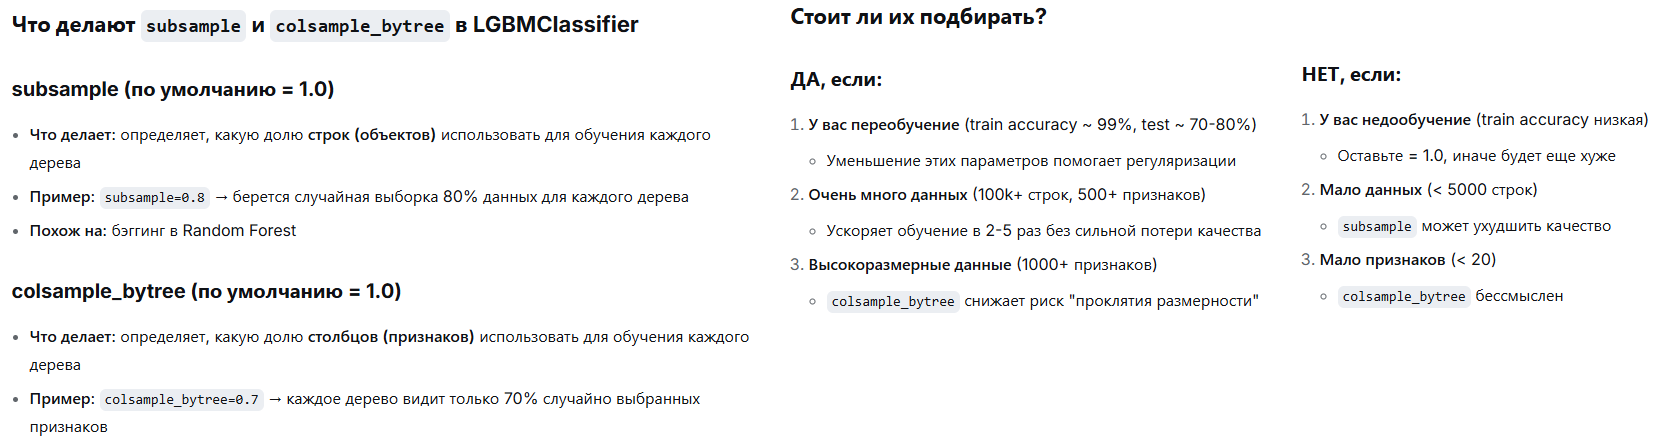

In [ ]:
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# с прерыванием и ранней остановкой
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import numpy as np

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_processed = X_train
X_test_processed = X_test
y_train_processed = y_train_enc
y_test_processed = y_test_enc

def objective(trial):
    params = {
        # https://lightgbm.readthedocs.io/en/v3.3.5/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 50),           # default=31
        'max_depth'         : trial.suggest_int('max_depth', 2, 10),             # default=-1
        'learning_rate'     : trial.suggest_float('learning_rate', 0.05, 0.3),   # default=0.1
        'n_estimators'      : trial.suggest_int('n_estimators', 10, 100),        # default=100
        'min_child_samples' : trial.suggest_int('min_child_samples', 20, 50),    # default=20   маленькое значение → больше узлов → медленнее
        # 'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),        # default=1.
        # 'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0), # default=1.

        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed, y_train_processed)):
        X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
        y_tr, y_val = y_train_processed[train_idx], y_train_processed[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )

        # Используем best_score_ (метрика по умолчанию - multi_logloss)
        # Для многоклассовой задачи метрика по умолчанию - multi_logloss (чем меньше, тем лучше)
        # Но нам нужна accuracy для сравнения
        # Поэтому лучше использовать model.score()
        fold_score = model.score(X_val, y_val)
        cv_scores.append(fold_score)

        trial.report(np.mean(cv_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)

study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
)
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

print("\nЛучшие параметры:")
print_aligned_dict(study.best_params)

# Финальная модель
final_model = lgb.LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
final_model.fit(X_train_processed, y_train_processed)

y_pred_encoded = final_model.predict(X_test_processed)

accuracy = accuracy_score(y_test_processed, y_pred_encoded)
f1 = f1_score(y_test_processed, y_pred_encoded, average='weighted')
recall = recall_score(y_test_processed, y_pred_encoded, average='weighted')
precision = precision_score(y_test_processed, y_pred_encoded, average='weighted')

print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)

grid_study_best_params = study.best_params

In [ ]:
# с прерыванием и ранней остановкой + дашборд
# https://www.kaggle.com/code/fconti748/ps-s4-ep4-optuna-dashboard-in-a-kaggle-notebook
# https://stackoverflow.com/questions/76033104/launching-optuna-dashboard-in-google-colaboratory
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import numpy as np

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_processed = X_train
X_test_processed = X_test
y_train_processed = y_train_enc
y_test_processed = y_test_enc

def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 50),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed, y_train_processed)):
        X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
        y_tr, y_val = y_train_processed[train_idx], y_train_processed[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )

        fold_score = model.score(X_val, y_val)
        cv_scores.append(fold_score)

        # --- ДОБАВЛЕНО: Сообщаем Optuna о промежуточном результате для каждого фолда ---
        # Это нужно для того, чтобы на графиках в дашборде отображался прогресс по шагам.
        trial.report(np.mean(cv_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
        # -----------------------------------------------------------------------

    return np.mean(cv_scores)

# --- ИЗМЕНЕНО: Создаем study с указанием storage (файл базы данных) ---
# Укажите имя для вашего файла, например, 'my_optuna_study.db'
study = optuna.create_study(
    study_name="lgbm_optimization",          # <-- ДОБАВЛЕНО: Даем понятное имя исследованию
    storage="sqlite:///my_optuna_study.db", # <-- ИЗМЕНЕНО: Добавлен storage
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
    load_if_exists=True                      # <-- ДОБАВЛЕНО: Позволяет переподключиться к существующему файлу
)
# ---------------------------------------------------------------------

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nЛучшие параметры:")
# Убедитесь, что функция print_aligned_dict определена, иначе используйте print(study.best_params)
print_aligned_dict(study.best_params)

# Финальная модель и оценка (остается без изменений)
final_model = lgb.LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
final_model.fit(X_train_processed, y_train_processed)

y_pred_encoded = final_model.predict(X_test_processed)

accuracy = accuracy_score(y_test_processed, y_pred_encoded)
f1 = f1_score(y_test_processed, y_pred_encoded, average='weighted')
recall = recall_score(y_test_processed, y_pred_encoded, average='weighted')
precision = precision_score(y_test_processed, y_pred_encoded, average='weighted')

print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)

grid_study_best_params = study.best_params

In [ ]:
# !ps aux | grep optuna-dashboard
# !netstat -tlnp | grep 8090
# !ps aux | grep ngrok
# !kill 108166

# !ngrok authtoken 2rDLisDE7TU2zCkc0xfSgmHD0rN_81FpGdewYSighKzTvjkRY
# !pip install pyngrok

In [ ]:
# Если нужно просто быстро глянуть результаты в коде:
import pandas as pd

# Загружаем триалы из БД
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))

# Показываем топ-5 по метрике
print("🏆 Топ-5 триалов:")
display(trials_df[trials_df['state'] == 'COMPLETE']
        .sort_values('value', ascending=False)  # direction='maximize'
        .head(10))

# Лучшие параметры (дублируем для удобства)
print("\n✅ Абсолютный чемпион:")
print_aligned_dict(study.best_params)

In [ ]:
# без прерывания
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import lightgbm as lgb  # ← ДОБАВИТЬ: для lgb.LGBMClassifier в конце

# Кодируем целевую переменную
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Приводим к единообразию (ДОБАВИТЬ)
X_train_processed = X_train
X_test_processed = X_test
y_train_processed = y_train_enc
y_test_processed = y_test_enc

def objective(trial):
    params = {
        # https://lightgbm.readthedocs.io/en/v3.3.5/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier
        'num_leaves'        : trial.suggest_int('num_leaves', 2, 14),            # default=31
        'max_depth'         : trial.suggest_int('max_depth', 2, 10),             # default=-1
        'learning_rate'     : trial.suggest_float('learning_rate', 0.05, 0.3),   # default=0.1
        'n_estimators'      : trial.suggest_int('n_estimators', 10, 200),        # default=100
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 50),     # default=20
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),        # default=1.
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0), # default=1.

        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    # Простая кросс-валидация, но с правильными y
    scores = cross_val_score(
        LGBMClassifier(**params),
        X_train_processed, y_train_processed,  # ← ИСПРАВЛЕНО
        cv=3,
        scoring='accuracy'
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective,
               n_trials=10,
               show_progress_bar=True
)

# Результаты
print("\nЛучшие параметры:")
print_aligned_dict(study.best_params)

# Финальная модель
final_model = lgb.LGBMClassifier(
    **study.best_params,
    random_state=42,
    verbose=-1
)
final_model.fit(X_train_processed, y_train_processed)  # ← ИСПРАВЛЕНО

# Оценка (предсказания в числах)
y_pred_encoded = final_model.predict(X_test_processed)  # ← ИСПРАВЛЕНО

# Обратно преобразуем в исходные метки (если нужно)
y_pred = le.inverse_transform(y_pred_encoded)
y_test_original = le.inverse_transform(y_test_processed)  # ← ИСПРАВЛЕНО

# Метрики (можно считать на закодированных или исходных)
accuracy = accuracy_score(y_test_processed, y_pred_encoded)  # ← ИСПРАВЛЕНО
f1 = f1_score(y_test_processed, y_pred_encoded, average='weighted')
recall = recall_score(y_test_processed, y_pred_encoded, average='weighted')
precision = precision_score(y_test_processed, y_pred_encoded, average='weighted')

print('')
print('Accuracy(test):  %.2f' % accuracy)
print('Recall(test):    %.2f' % recall)
print('Precision(test): %.2f' % precision)
print('F1(test)         %.2f' % f1)
print('')

grid_study_best_params = study.best_params

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
optuna.visualization.plot_parallel_coordinate(study)

In [ ]:
# ✅ Способ 4: Процентный порог (топ X%)
# Берем топ 20% лучших попыток
percentile = 80  # топ 20% (80-й перцентиль и выше)

# Получаем все значения accuracy
values = [t.value for t in study.trials if t.value is not None]
threshold = np.percentile(values, percentile)

print(f"Порог для топ 20%: {threshold:.4f}")

# Фильтруем
filtered_study = optuna.create_study(direction='maximize')
for trial in study.trials:
    if trial.value is not None and trial.value >= threshold:
        filtered_study.add_trial(trial)

# Строим график
fig = optuna.visualization.plot_parallel_coordinate(
    filtered_study,
    # params=['max_depth', 'n_estimators']
)
fig.show()

print(f"Показано {len(filtered_study.trials)} попыток из {len(study.trials)}")

In [ ]:
optuna.visualization.plot_slice(study)


# ==================================================================
# fig = optuna.visualization.plot_contour(
#     study,
#     # params=['max_depth', 'max_features', 'n_estimators']
# )
# fig.show()

# ==================================================================
# optuna.visualization.plot_rank(study)

##Финальное обучение лучшей модели с early stopping и сохранение в файл

In [ ]:
study

In [ ]:
import json
import os
import pickle
import lightgbm as lgb

# 2️⃣ Финальное обучение лучшей модели с early stopping
final_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1,                 # Отключаем вывод (будем использовать callbacks)
    **grid_study_best_params,       # Лучшие параметры
)


# Обучаем с валидацией и ранней остановкой
final_model.fit(
    X_train_part, y_train_part,
    eval_set=(X_val, y_val),
    # eval_metric='multi_logloss',  # Метрика для ранней остановки
    eval_metric=['multi_logloss', 'multi_error'],  # Несколько метрик
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),  # Ранняя остановка
        lgb.log_evaluation(period=50)            # Вывод каждые 50 итераций
    ]
)

# 3️⃣ Оценка на тестовой выборке (которую модель не видела НИКОГДА)
y_pred = final_model.predict(X_test)

# Оценка качества
print('')
print('Accuracy(test):  %.2f' % accuracy_score(y_test, y_pred))
print('Recall(test):    %.2f' % recall_score(y_test, y_pred, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test, y_pred, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test, y_pred, average='weighted'))
print('')

print_aligned_dict(final_model.get_params())

# 1. Сохраняем модель в нативном формате LightGBM (txt)
# ✅ Все деревья и их веса
# ✅ Параметры модели (num_leaves, max_depth, learning_rate, n_estimators и т.д.)
# ✅ Feature names (если были)
# ✅ Целевая метрика (eval_metric)
# ✅ Внутреннее состояние модели
# ✅ Пороги для бинаризации признаков
os.makedirs('/content/lightgbm_info', exist_ok=True)
final_model.booster_.save_model('/content/lightgbm_info/lightgbm_model.txt')

# 2. Сохраняем также в формате pickle (для быстрой загрузки в Python)
with open('/content/lightgbm_info/lightgbm_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# 3. Сохраняем мета-информацию (параметры, метрики и т.д.)
model_info = {
    'model_type': 'LightGBMClassifier',
    'n_estimators': final_model.n_estimators,
    'best_iteration': final_model.best_iteration_,
    'feature_names': list(X_train.columns) if hasattr(X_train, 'columns') else None,
    'num_classes': final_model.n_classes_,
    'objective': final_model.objective_,
    'best_score': final_model.best_score_,
    'params': final_model.get_params()
}

with open('/content/lightgbm_info/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

# 4. Дополнительно: сохраняем важность признаков (feature importance)
feature_importance = {
    'feature_names': model_info['feature_names'],
    'split_importance': final_model.booster_.feature_importance(importance_type='split').tolist(),
    'gain_importance': final_model.booster_.feature_importance(importance_type='gain').tolist()
}

with open('/content/lightgbm_info/feature_importance.json', 'w') as f:
    json.dump(feature_importance, f, indent=2)


# Экспорт в формат для production (C++ API)
# final_model.booster_.save_model('/content/lightgbm_info/lightgbm_model.txt', num_iteration=final_model.best_iteration_)

print(f"\n✅ Модель сохранена в /content/lightgbm_info/")
print(f"   - lightgbm_model.txt (нативный формат LightGBM)")
print(f"   - lightgbm_model.pkl (pickle формат)")
print(f"   - model_info.json (мета-информация)")
print(f"   - feature_importance.json (важность признаков)")

##Отрисовка графика

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Получаем историю обучения
evals_result = final_model.evals_result_

# Определяем ключ датасета
dataset_key = list(evals_result.keys())[0]  # 'valid_0'

# Получаем данные для первого графика (multi_logloss)
metric_name = list(evals_result[dataset_key].keys())[0]  # 'multi_logloss'
logloss_values = evals_result[dataset_key][metric_name]

# Получаем данные для второго графика (accuracy из multi_error)
multi_error_values = evals_result[dataset_key]['multi_error']
accuracy_values = [1 - err for err in multi_error_values]

# Лучшая итерация по logloss
best_iteration_logloss = final_model.best_iteration_
best_logloss = logloss_values[best_iteration_logloss - 1]

# Лучшая итерация по accuracy
best_accuracy_iter = np.argmax(accuracy_values) + 1
best_accuracy = accuracy_values[best_accuracy_iter - 1]

# Создаем figure с двумя подграфиками (один слева, один справа)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== Левый график: Logloss ==========
ax1.plot(logloss_values, linewidth=2, color='blue', label=f'Validation {metric_name}')
ax1.axvline(x=best_iteration_logloss, color='red', linestyle='--', alpha=0.7,
            label=f'Best iteration: {best_iteration_logloss}')
ax1.set_xlabel('Iteration (number of trees)')
ax1.set_ylabel(metric_name.upper())
ax1.set_title(f'LightGBM Training Process\nBest {metric_name}: {best_logloss:.4f}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ========== Правый график: Accuracy ==========
ax2.plot(accuracy_values, linewidth=2, color='green', label='Validation Accuracy')
ax2.axvline(x=best_iteration_logloss, color='red', linestyle='--', alpha=0.7,
            label=f'Early stop iteration: {best_iteration_logloss} (by logloss)')
ax2.axvline(x=best_accuracy_iter, color='orange', linestyle=':', alpha=0.7,
            label=f'Best accuracy iteration: {best_accuracy_iter}')
ax2.plot(best_accuracy_iter, best_accuracy, 'ro', markersize=8)

# Аннотация с лучшей accuracy
ax2.annotate(f'  Best Accuracy: {best_accuracy:.4f}',
             xy=(best_accuracy_iter, best_accuracy),
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.set_xlabel('Iteration (number of trees)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy\n(calculated from multi_error)')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Общий заголовок
fig.suptitle('LightGBM Training Process: Logloss vs Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Выводим дополнительную информацию
print(f"\n📊 Статистика обучения:")
print(f"   Ранняя остановка (по multi_logloss) на итерации: {best_iteration_logloss}")
print(f"   Лучшая multi_logloss: {best_logloss:.4f}")
print(f"   Лучшая accuracy: {best_accuracy:.4f} на итерации: {best_accuracy_iter}")
print(f"   Accuracy на итерации ранней остановки: {accuracy_values[best_iteration_logloss-1]:.4f}")

##Считывание из файла и финальный прогон

In [ ]:
import lightgbm as lgb
import pickle
import json
import os
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Загрузка моделей
print("Загрузка моделей...")
loaded_model_txt = lgb.Booster(model_file='/content/lightgbm_info/lightgbm_model.txt')

with open('/content/lightgbm_info/lightgbm_model.pkl', 'rb') as f:
    loaded_model_pickle = pickle.load(f)

# Предсказания для .txt модели
y_pred_txt = loaded_model_txt.predict(X_test)
y_pred_txt_classes = np.argmax(y_pred_txt, axis=1)  # числа (0, 1, 2...)

# Предсказания для pickle модели
y_pred_pkl = loaded_model_pickle.predict(X_test)  # строки или числа?

# Определяем тип y_test и приводим всё к единому формату
print("\n" + "="*60)
print("ДИАГНОСТИКА ТИПОВ ДАННЫХ")
print("="*60)
print(f"Тип y_test: {type(y_test[0]) if hasattr(y_test, '__getitem__') else 'unknown'}")
print(f"Тип y_pred_pkl[0]: {type(y_pred_pkl[0])}")
print(f"Уникальные значения y_test: {np.unique(y_test)[:5]}")
print(f"Уникальные значения y_pred_pkl: {np.unique(y_pred_pkl)[:5]}")

# Приводим к единому формату (числовому)
if isinstance(y_pred_pkl[0], str):
    # Преобразуем строковые предсказания в числа
    unique_classes = sorted(np.unique(y_train))  # или np.unique(y_test)
    class_to_int = {cls: i for i, cls in enumerate(unique_classes)}
    y_pred_pkl_numeric = np.array([class_to_int[cls] for cls in y_pred_pkl])

    # Преобразуем y_test в числа, если нужно
    if isinstance(y_test[0] if hasattr(y_test, '__getitem__') else y_test, str):
        y_test_numeric = np.array([class_to_int[cls] for cls in y_test])
    else:
        y_test_numeric = y_test
else:
    y_pred_pkl_numeric = y_pred_pkl
    y_test_numeric = y_test

# Для txt модели используем те же y_test_numeric
if isinstance(y_test[0] if hasattr(y_test, '__getitem__') else y_test, str):
    if 'y_test_numeric' not in locals():
        unique_classes = sorted(np.unique(y_train))
        class_to_int = {cls: i for i, cls in enumerate(unique_classes)}
        y_test_numeric = np.array([class_to_int[cls] for cls in y_test])
else:
    y_test_numeric = y_test

# Оценка качества для .txt модели
print('\n' + '='*60)
print('ЗАГРУЗКА ИЗ NATIVE .txt ФОРМАТА (Booster)')
print('='*60)
print('Accuracy(test txt):  %.4f' % accuracy_score(y_test_numeric, y_pred_txt_classes))
print('Recall(test txt):    %.4f' % recall_score(y_test_numeric, y_pred_txt_classes, average='weighted'))
print('Precision(test txt): %.4f' % precision_score(y_test_numeric, y_pred_txt_classes, average='weighted'))
print('F1(test txt):        %.4f' % f1_score(y_test_numeric, y_pred_txt_classes, average='weighted'))

# Оценка качества для pickle модели
print('\n' + '='*60)
print('ЗАГРУЗКА ИЗ .pkl ФОРМАТА (LGBMClassifier)')
print('='*60)
print('Accuracy(test pkl):  %.4f' % accuracy_score(y_test_numeric, y_pred_pkl_numeric))
print('Recall(test pkl):    %.4f' % recall_score(y_test_numeric, y_pred_pkl_numeric, average='weighted'))
print('Precision(test pkl): %.4f' % precision_score(y_test_numeric, y_pred_pkl_numeric, average='weighted'))
print('F1(test pkl):        %.4f' % f1_score(y_test_numeric, y_pred_pkl_numeric, average='weighted'))

# Проверяем, что обе модели дают одинаковые результаты
if np.array_equal(y_pred_txt_classes, y_pred_pkl_numeric):
    print("\n✅ Модели дают одинаковые предсказания!")
else:
    diff_count = np.sum(y_pred_txt_classes != y_pred_pkl_numeric)
    print(f"\n⚠️ Модели дают разные предсказания!")
    print(f"   Разница: {diff_count} из {len(y_pred_txt_classes)} ({diff_count/len(y_pred_txt_classes)*100:.2f}%)")

# Дополнительно: метрики по каждому классу
if len(np.unique(y_test_numeric)) <= 10:
    print("\n" + "="*60)
    print("МЕТРИКИ ПО КАЖДОМУ КЛАССУ (по pickle модели)")
    print("="*60)

    # Получаем исходные названия классов
    if hasattr(y_train, 'unique') and isinstance(y_train.iloc[0] if hasattr(y_train, 'iloc') else y_train[0], str):
        class_names = sorted(np.unique(y_train))
    else:
        class_names = [str(i) for i in sorted(np.unique(y_test_numeric))]

    print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-"*65)

    for i, class_name in enumerate(class_names):
        # Создаем бинарные метки для текущего класса
        y_test_binary = (y_test_numeric == i).astype(int)
        y_pred_binary = (y_pred_pkl_numeric == i).astype(int)

        p = precision_score(y_test_binary, y_pred_binary, zero_division=0)
        r = recall_score(y_test_binary, y_pred_binary, zero_division=0)
        f = f1_score(y_test_binary, y_pred_binary, zero_division=0)
        support = np.sum(y_test_binary)

        print(f"{str(class_name):<15} {p:<12.4f} {r:<12.4f} {f:<12.4f} {support:<10}")

# Загружаем мета-информацию
if os.path.exists('/content/lightgbm_info/model_info.json'):
    with open('/content/lightgbm_info/model_info.json', 'r') as f:
        loaded_info = json.load(f)

    print(f"\n" + "="*60)
    print("📋 ИНФОРМАЦИЯ О МОДЕЛИ")
    print("="*60)
    print(f"   Тип модели: {loaded_info['model_type']}")
    print(f"   Количество деревьев (n_estimators): {loaded_info['n_estimators']}")
    print(f"   Лучшая итерация: {loaded_info['best_iteration']}")
    print(f"   Количество классов: {loaded_info['num_classes']}")
    if 'objective' in loaded_info:
        print(f"   Objective: {loaded_info['objective']}")

    if 'params' in loaded_info:
        print(f"\n   Параметры модели:")
        # Ограничим вывод основных параметров
        important_params = ['num_leaves', 'max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree']
        for key in important_params:
            if key in loaded_info['params']:
                print(f"      {key}: {loaded_info['params'][key]}")

#XGBoost

In [ ]:
# Основные параметры XGBoost:
# n_estimators - количество деревьев в ансамбле
#   Чем больше, тем сложнее модель, но растет риск переобучения
#   Обычно 100-1000, но можно использовать раннюю остановку

# learning_rate - скорость обучения (eta)
#   Уменьшает вклад каждого нового дерева (обычно 0.01-0.3)
#   Меньшее значение требует больше деревьев, но часто дает лучшее качество

# max_depth - максимальная глубина деревьев
#   Ограничивает глубину дерева (по умолчанию 6)
#   Обычно 3-10, помогает контролировать переобучение

# min_child_weight - минимальная сумма весов в листе
#   Аналог min_child_samples в LightGBM
#   Защищает от слишком глубоких веток, обычно 1-10

# subsample - доля выборки для обучения каждого дерева (bagging)
#   Помогает бороться с переобучением, обычно 0.5-0.9

# colsample_bytree - доля признаков для обучения каждого дерева
#   Помогает бороться с переобучением, обычно 0.5-0.9

# colsample_bylevel - доля признаков для каждого уровня дерева
#   Дополнительный контроль переобучения

# reg_alpha и reg_lambda - L1 и L2 регуляризация (alpha, lambda)
#   Помогают контролировать сложность модели

# gamma - минимальное уменьшение функции потерь для создания нового узла
#   Чем больше, тем консервативнее модель (аналог min_split_loss)

import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Кодируем строковые метки классов в числа
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Выводим соответствие классов
print("Соответствие классов:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i} -> {class_name}")
print()

# Разделяем на обучающую и валидационную выборки
# Преобразовать X_train и X_test в numpy массивы в самом начале
X_train = X_train.values if hasattr(X_train, 'values') else X_train
X_test = X_test.values if hasattr(X_test, 'values') else X_test
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train_encoded, test_size=0.2, random_state=42
)

# Создаем модель XGBoost
xgboost_model = xgb.XGBClassifier(
    n_estimators=500,          # Количество деревьев (аналог iterations)
    learning_rate=0.1,         # Скорость обучения (eta - шаг градиентного спуска)
    max_depth=3,               # Максимальная глубина деревьев (в XGBoost нет num_leaves)
    min_child_weight=5,        # Минимальная сумма весов в листе (аналог min_child_samples)
    subsample=0.8,             # Доля выборки для обучения каждого дерева (bagging)
    colsample_bytree=0.8,      # Доля признаков для каждого дерева
    colsample_bylevel=0.8,     # Доля признаков для каждого уровня дерева
    reg_alpha=0.1,             # L1 регуляризация (alpha)
    reg_lambda=0.1,            # L2 регуляризация (lambda)
    gamma=0,                   # Минимальное уменьшение потерь для создания узла
    random_state=42,           # Фиксация случайности для воспроизводимости
    n_jobs=-1,                 # Использовать все ядра процессора
    verbosity=0,               # Уровень вывода (0 - молча, 1 - предупреждения, 2 - информация)
    eval_metric='mlogloss',    # Метрика для оценки (multi-class log loss)
    early_stopping_rounds=50,  # Ранняя остановка (аналог stopping_rounds)
)

# Обучаем модель с валидацией и ранней остановкой
xgboost_model.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],          # Валидационная выборка (список кортежей)
    verbose=50                         # Вывод каждые 50 итераций (по умолчанию)
)

# Предсказания (возвращаются числовые метки)
y_pred_encoded = xgboost_model.predict(X_test)

# Преобразуем обратно в строковые метки для интерпретации результатов
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Оценка качества (используем закодированные значения для метрик)
print("Результаты на тестовой выборке:")
print('Accuracy(test):  %.2f' % accuracy_score(y_test_encoded, y_pred_encoded))
print('Recall(test):    %.2f' % recall_score(y_test_encoded, y_pred_encoded, average='weighted'))
print('Precision(test): %.2f' % precision_score(y_test_encoded, y_pred_encoded, average='weighted'))
print('F1(test):        %.2f' % f1_score(y_test_encoded, y_pred_encoded, average='weighted'))

# Лучшее количество итераций (деревьев)
if hasattr(xgboost_model, 'best_iteration'):
    print(f"Оптимальное количество деревьев: {xgboost_model.best_iteration}")
else:
    print(f"Оптимальное количество деревьев: {xgboost_model.best_iteration}")

# Выводим пример предсказаний
print("\nПример предсказаний (первые 10):")
for i in range(min(10, len(y_pred))):
    print(f"  Истинный класс: {y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]}, "
          f"Предсказанный класс: {y_pred[i]}")

# Если нужно получить вероятности для каждого класса
y_pred_proba = xgboost_model.predict_proba(X_test)
print(f"\nВероятности предсказаний для первых 5 примеров (формат: {len(label_encoder.classes_)} классов):")
print(y_pred_proba[:5])

In [ ]:
# построить диаграмму значимости признаков для XGBoost
importances = xgboost_model.feature_importances_
indices = np.argsort(importances)[::-1]
feat_labels = df.columns[1:]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (
        f + 1,
        30,
        feat_labels[indices[f]],
        importances[indices[f]])
    )

# plt.t('Feature Importance')
plt.bar(range(X_train.shape[1]),
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
#plt.savefig('images/04_09.png', dpi=300)
plt.show()

In [ ]:
# Накопленная значимость признаков для XGBoost
importances = xgboost_model.feature_importances_
indices = np.argsort(importances)[::-1]

sorted_importances = importances[indices]
# Нормируем важности, чтобы их сумма была равна 1
sorted_importances = sorted_importances / sorted_importances.sum()
cumulative_importances = np.cumsum(sorted_importances)

# График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Отдельные важности
ax1.bar(range(len(importances)), sorted_importances, align='center', color='steelblue')
ax1.set_xlabel('Feature Index')
ax1.set_ylabel('Importance')
ax1.set_title('Individual Feature Importance')

# Накопленная важность
ax2.plot(range(1, len(importances) + 1), cumulative_importances, 'bo-', linewidth=2)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Находим сколько признаков нужно для 95% важности
n_for_95 = np.where(cumulative_importances >= 0.95)[0][0] + 1
print(f"Для достижения 95% важности нужно {n_for_95} признаков")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import xgboost as xgb
import numpy as np

# ============================================================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================================================

# Кодируем строковые метки классов в числа
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Выводим соответствие классов
print("Соответствие классов:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i} -> {class_name}")
print()

# ============================================================================
# 2. НАСТРОЙКА CALLBACK ДЛЯ ВЫВОДА ПРОЦЕССА ОБУЧЕНИЯ
# ============================================================================

# Создаем callback для вывода метрик на каждой итерации
def evaluation_callback(env):
    """Callback для вывода метрик в процессе обучения"""
    if env.iteration % 10 == 0:  # Выводим каждые 10 итераций
        # Проверяем, есть ли метрики для train и validation
        if len(env.evaluation_result_list) >= 2:
            print(f"    Итерация {env.iteration:3d}: "
                  f"train_mlogloss={env.evaluation_result_list[0][1]:.6f}, "
                  f"valid_mlogloss={env.evaluation_result_list[1][1]:.6f}")
        elif len(env.evaluation_result_list) >= 1:
            print(f"    Итерация {env.iteration:3d}: "
                  f"train_mlogloss={env.evaluation_result_list[0][1]:.6f}")

# Оборачиваем XGBClassifier, чтобы автоматически добавлять callback
class XGBWithCallback(xgb.XGBClassifier):
    """XGBClassifier с автоматическим добавлением callback для вывода процесса обучения"""

    def fit(self, X, y, **kwargs):
        # Добавляем callback если есть eval_set
        if 'eval_set' in kwargs and kwargs['eval_set']:
            if 'callbacks' not in kwargs:
                kwargs['callbacks'] = []
            # Добавляем наш callback, если его еще нет
            if evaluation_callback not in kwargs['callbacks']:
                kwargs['callbacks'].append(evaluation_callback)
        return super().fit(X, y, **kwargs)

# ============================================================================
# 3. НАСТРОЙКА ПАРАМЕТРОВ ДЛЯ ПОИСКА
# ============================================================================

# Параметры для перебора (адаптировано для XGBoost)
param_grid = {
    'max_depth': [2, 3, 4],              # Максимальная глубина дерева
    'learning_rate': [0.05, 0.1, 0.15]   # Скорость обучения
}

# Базовые параметры модели (используем XGBWithCallback вместо стандартного XGBClassifier)
xgboost_model = XGBWithCallback(
    n_estimators=200,        # Количество деревьев (фиксировано для подбора)
    random_state=42,         # Фиксация случайности
    verbosity=1,             # Отключаем стандартный вывод XGBoost (используем свой callback)
    n_jobs=-1,               # Используем все ядра CPU
    eval_metric='mlogloss',  # Метрика для multi-class классификации
)

# ============================================================================
# 4. НАСТРОЙКА GRIDSEARCHCV
# ============================================================================

# GridSearchCV (n_jobs=1 важно для последовательного вывода callback'ов)
grid = GridSearchCV(
    xgboost_model,
    param_grid,
    cv=3,                    # 3-кратная кросс-валидация
    scoring='accuracy',      # Метрика для оценки
    n_jobs=1,                # Важно: 1, чтобы вывод callback'ов не перемешивался
    refit=True,              # Переобучить на всех данных после поиска
    verbose=3                # Уровень детализации вывода (2 - достаточно информативно)
)

# ============================================================================
# 5. ОБУЧЕНИЕ С ВЫВОДОМ ПРОЦЕССА
# ============================================================================

print("="*60)
print("НАЧАЛО ПЕРЕБОРА ПАРАМЕТРОВ С ВЫВОДОМ ПРОЦЕССА ОБУЧЕНИЯ")
print("="*60)
print(f"Всего комбинаций: {len(param_grid['max_depth']) * len(param_grid['learning_rate'])}")
print(f"Количество фолдов: 3")
print(f"Всего обучений: {len(param_grid['max_depth']) * len(param_grid['learning_rate']) * 3}")
print("="*60)
print()

# Обучаем на закодированных метках
grid.fit(X_train, y_train_encoded)

# ============================================================================
# 6. ЛУЧШАЯ МОДЕЛЬ И ПРЕДСКАЗАНИЯ
# ============================================================================

# Лучшая модель
best_model = grid.best_estimator_

# Предсказания на тестовой выборке (числовые метки)
y_pred_encoded = best_model.predict(X_test)

# Преобразуем обратно в строковые метки для интерпретации
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_test_original = label_encoder.inverse_transform(y_test_encoded)

# ============================================================================
# 7. ОЦЕНКА КАЧЕСТВА
# ============================================================================

print('\n' + '='*60)
print('РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:')
print('='*60)
print('Accuracy(test):  %.4f' % accuracy_score(y_test_encoded, y_pred_encoded))
print('Recall(test):    %.4f' % recall_score(y_test_encoded, y_pred_encoded, average='weighted'))
print('Precision(test): %.4f' % precision_score(y_test_encoded, y_pred_encoded, average='weighted'))
print('F1(test):        %.4f' % f1_score(y_test_encoded, y_pred_encoded, average='weighted'))

# ============================================================================
# 8. ИНФОРМАЦИЯ О ПОИСКЕ ПАРАМЕТРОВ
# ============================================================================

print('\n' + '='*60)
print('ИНФОРМАЦИЯ О ПОИСКЕ ПАРАМЕТРОВ:')
print('='*60)
print(f"Лучшая accuracy на кросс-валидации: {grid.best_score_:.4f}")
print(f"Лучшие параметры:")
for param, value in grid.best_params_.items():
    print(f"  {param:20s}: {value}")
print(f"\nВсего комбинаций параметров: {len(grid.cv_results_['params'])}")
print(f"Лучшая модель обучена на {grid.n_splits_} фолдах")

# ============================================================================
# 9. ПРИМЕРЫ ПРЕДСКАЗАНИЙ
# ============================================================================

print('\n' + '='*60)
print('ПРИМЕР ПРЕДСКАЗАНИЙ (первые 20):')
print('='*60)
correct_count = 0
for i in range(min(20, len(y_pred))):
    is_correct = y_test_original[i] == y_pred[i]
    correct_count += is_correct
    status = "✓" if is_correct else "✗"
    print(f"{status} {i+1:2d}. Истинный: {y_test_original[i]:20s} -> Предсказанный: {y_pred[i]:20s}")

print(f"\nТочность на первых {min(20, len(y_pred))} примерах: {correct_count/min(20, len(y_pred)):.0%}")

# ============================================================================
# 10. ВЕРОЯТНОСТИ ПРЕДСКАЗАНИЙ
# ============================================================================

# Если нужно получить вероятности для каждого класса
y_pred_proba = best_model.predict_proba(X_test)
print('\n' + '='*60)
print('ВЕРОЯТНОСТИ ПРЕДСКАЗАНИЙ:')
print('='*60)
print(f"Вероятности для первых 3 примеров (всего {len(label_encoder.classes_)} классов):")
for i in range(min(3, len(y_pred_proba))):
    print(f"\nПример {i+1}:")
    # Показываем топ-3 наиболее вероятных класса
    top_3_idx = y_pred_proba[i].argsort()[-3:][::-1]
    for idx in top_3_idx:
        print(f"  {label_encoder.classes_[idx]:20s}: {y_pred_proba[i][idx]:.4f}")

# ============================================================================
# 11. ФУНКЦИЯ ДЛЯ КРАСИВОГО ВЫВОДА СЛОВАРЯ
# ============================================================================

def print_aligned_dict(d):
    """Выводит словарь с выравниванием"""
    if d:
        max_key_len = max(len(str(k)) for k in d.keys())
        for key, value in d.items():
            print(f"  {str(key):<{max_key_len}} : {value}")
    else:
        print("  Словарь пуст")

# Выводим лучшие параметры в форматированном виде
print('\n' + '='*60)
print('ЛУЧШИЕ ПАРАМЕТРЫ (форматированный вывод):')
print('='*60)
print_aligned_dict(grid.best_params_)

# ============================================================================
# 12. ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ ОБ ОБУЧЕНИИ
# ============================================================================

print('\n' + '='*60)
print('ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:')
print('='*60)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Количество классов: {len(label_encoder.classes_)}")
print(f"Параметры лучшей модели:")
for param, value in best_model.get_params().items():
    if param in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']:
        print(f"  {param:20s}: {value}")

In [ ]:
import json
import os
import pickle
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Убедимся, что y_test закодирован в числа
# Если y_test еще не закодирован, нужно это сделать
if isinstance(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0], str):
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
else:
    y_test_encoded = y_test

# 2️⃣ Финальное обучение лучшей модели с early stopping
final_model = xgb.XGBClassifier(
    n_estimators=500,
    random_state=42,
    verbosity=1,
    n_jobs=-1,
    eval_metric=['mlogloss', 'merror'],
    early_stopping_rounds=50,
    **grid.best_params_
)

# Обучаем с валидацией и ранней остановкой
final_model.fit(
    X_train_part, y_train_part,
    eval_set=[(X_train_part, y_train_part), (X_val, y_val)],
    verbose=50
)

# 3️⃣ Оценка на тестовой выборке
y_pred_encoded = final_model.predict(X_test)

# Для обратного преобразования в строки (если нужно)
if 'label_encoder' in locals():
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    y_test_original = label_encoder.inverse_transform(y_test_encoded)
else:
    y_pred = y_pred_encoded
    y_test_original = y_test_encoded

# Оценка качества - используем закодированные версии для метрик
print('\n' + '='*60)
print('РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:')
print('='*60)
print('Accuracy(test):  %.4f' % accuracy_score(y_test_encoded, y_pred_encoded))
print('Recall(test):    %.4f' % recall_score(y_test_encoded, y_pred_encoded, average='weighted'))
print('Precision(test): %.4f' % precision_score(y_test_encoded, y_pred_encoded, average='weighted'))
print('F1(test):        %.4f' % f1_score(y_test_encoded, y_pred_encoded, average='weighted'))

# 1. Сохраняем модель в нативном формате XGBoost
os.makedirs('/content/xgboost_info', exist_ok=True)

# Сохраняем в формате JSON
final_model.get_booster().save_model('/content/xgboost_info/xgboost_model.json')
print("✅ Модель сохранена в формате JSON")

# 2. Сохраняем также в формате pickle
with open('/content/xgboost_info/xgboost_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# 3. Сохраняем мета-информацию
# Получаем историю обучения
evals_result = final_model.evals_result()

# Определяем лучшие значения метрик
if hasattr(final_model, 'best_iteration') and final_model.best_iteration is not None:
    best_iteration = final_model.best_iteration
else:
    best_iteration = final_model.best_ntree_limit if hasattr(final_model, 'best_ntree_limit') else final_model.n_estimators

# Получаем значения метрик
try:
    if 'merror' in evals_result.get('validation_1', {}):
        val_merror = evals_result['validation_1']['merror'][best_iteration - 1]
        val_accuracy = 1 - val_merror
    else:
        val_accuracy = None
except (IndexError, KeyError):
    val_accuracy = None

try:
    if 'mlogloss' in evals_result.get('validation_1', {}):
        val_mlogloss = evals_result['validation_1']['mlogloss'][best_iteration - 1]
    else:
        val_mlogloss = None
except (IndexError, KeyError):
    val_mlogloss = None

# Сохраняем label encoder если он был создан
if 'label_encoder' in locals():
    with open('/content/xgboost_info/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)

model_info = {
    'model_type': 'XGBoostClassifier',
    'xgboost_version': xgb.__version__,
    'n_estimators': final_model.n_estimators,
    'best_iteration': int(best_iteration),
    'best_ntree_limit': int(getattr(final_model, 'best_ntree_limit', best_iteration)),
    'feature_names': list(X_train.columns) if hasattr(X_train, 'columns') else None,
    'num_classes': final_model.n_classes_,
    'objective': final_model.objective,
    'best_score': {
        'best_accuracy': float(val_accuracy) if val_accuracy is not None else None,
        'best_mlogloss': float(val_mlogloss) if val_mlogloss is not None else None,
        'best_iteration': int(best_iteration)
    },
    'params': {k: str(v) for k, v in final_model.get_params().items()},
    'training_info': {
        'n_features': X_train.shape[1] if hasattr(X_train, 'shape') else None,
        'n_train_samples': len(X_train_part) if hasattr(X_train_part, 'shape') else None,
        'n_val_samples': len(X_val) if hasattr(X_val, 'shape') else None,
        'n_test_samples': len(X_test) if hasattr(X_test, 'shape') else None
    }
}

with open('/content/xgboost_info/xgboost_model_info.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

# 4. Сохраняем историю обучения
training_history = {}
for dataset_name, metrics in evals_result.items():
    training_history[dataset_name] = {}
    for metric_name, values in metrics.items():
        training_history[dataset_name][metric_name] = values.tolist() if hasattr(values, 'tolist') else values

with open('/content/xgboost_info/xgboost_training_history.json', 'w') as f:
    json.dump(training_history, f, indent=2)

# 5. Сохраняем важность признаков
feature_names = model_info['feature_names']
if feature_names is None:
    feature_names = [f'f{i}' for i in range(final_model.n_features_in_)]

# Базовый weight importance
weight_importance = final_model.feature_importances_.tolist()

# Получаем различные типы важности
booster = final_model.get_booster()
gain_importance_dict = booster.get_score(importance_type='gain')
cover_importance_dict = booster.get_score(importance_type='cover')
total_gain_dict = booster.get_score(importance_type='total_gain')
total_cover_dict = booster.get_score(importance_type='total_cover')

# Создаем списки для всех признаков
gain_importance = []
cover_importance = []
total_gain_importance = []
total_cover_importance = []

for i, fname in enumerate(feature_names):
    fname_str = str(fname)
    gain_importance.append(gain_importance_dict.get(fname_str, 0.0))
    cover_importance.append(cover_importance_dict.get(fname_str, 0.0))
    total_gain_importance.append(total_gain_dict.get(fname_str, 0.0))
    total_cover_importance.append(total_cover_dict.get(fname_str, 0.0))

feature_importance = {
    'feature_names': feature_names,
    'weight_importance': weight_importance,
    'gain_importance': gain_importance,
    'cover_importance': cover_importance,
    'total_gain_importance': total_gain_importance,
    'total_cover_importance': total_cover_importance
}

# Создаем версию с сортировкой
for importance_type in ['weight_importance', 'gain_importance', 'cover_importance',
                         'total_gain_importance', 'total_cover_importance']:
    if importance_type in feature_importance:
        features_with_importance = list(zip(feature_names, feature_importance[importance_type]))
        features_with_importance.sort(key=lambda x: x[1], reverse=True)
        feature_importance[f'{importance_type}_sorted'] = [
            {'feature': f, 'importance': float(v)} for f, v in features_with_importance
        ]

with open('/content/xgboost_info/xgboost_feature_importance.json', 'w') as f:
    json.dump(feature_importance, f, indent=2)

# 6. Сохраняем параметры для inference
inference_config = {
    'nthread': -1,
    'verbosity': 0,
    'predictor': 'cpu_predictor',
    'tree_method': 'auto'
}

with open('/content/xgboost_info/xgboost_inference_config.json', 'w') as f:
    json.dump(inference_config, f, indent=2)

# 7. Создаем скрипт для загрузки модели
inference_script = f'''"""
Пример загрузки и использования сохраненной модели XGBoost
"""

import xgboost as xgb
import pickle
import json
import numpy as np

# Способ 1: Загрузка из JSON (рекомендуется для production)
print("Загрузка модели из JSON...")
model = xgb.XGBClassifier()
model.get_booster().load_model('xgboost_model.json')

# Загрузка label encoder (если нужно преобразовывать обратно в строки)
try:
    with open('label_encoder.pkl', 'rb') as f:
        label_encoder = pickle.load(f)
    print("Label encoder загружен")
except:
    label_encoder = None
    print("Label encoder не найден")

# Загрузка мета-информации
with open('xgboost_model_info.json', 'r') as f:
    info = json.load(f)

print(f"Модель загружена: {{info['model_type']}}")
print(f"Лучшая итерация: {{info['best_iteration']}}")
print(f"Количество классов: {{info['num_classes']}}")

# Пример предсказания
def predict_with_labels(X_new):
    """Предсказание с возвратом строковых меток"""
    predictions_encoded = model.predict(X_new)
    if label_encoder:
        return label_encoder.inverse_transform(predictions_encoded)
    return predictions_encoded

def predict_proba_with_labels(X_new):
    """Предсказание вероятностей с возвратом названий классов"""
    probabilities = model.predict_proba(X_new)
    if label_encoder:
        return {{'classes': label_encoder.classes_.tolist(), 'probabilities': probabilities.tolist()}}
    return probabilities

print("Модель готова к использованию!")
'''

with open('/content/xgboost_info/xgboost_load_model_example.py', 'w', encoding='utf-8') as f:
    f.write(inference_script)

# Вывод информации
print(f"\n✅ Модель сохранена в /content/xgboost_info/")
print(f"\n📁 Сохраненные файлы:")
print(f"   - xgboost_model.json (нативный формат XGBoost JSON)")
print(f"   - xgboost_model.pkl (pickle формат)")
print(f"   - label_encoder.pkl (кодировщик классов)")
print(f"   - xgboost_model_info.json (мета-информация)")
print(f"   - xgboost_training_history.json (история обучения)")
print(f"   - xgboost_feature_importance.json (важность признаков)")
print(f"   - xgboost_inference_config.json (конфигурация для инференса)")
print(f"   - xgboost_load_model_example.py (пример загрузки модели)")

# Вывод статистики обучения
print(f"\n📊 Статистика обучения XGBoost:")
print(f"   Лучшая итерация: {best_iteration}")
if val_mlogloss:
    print(f"   Лучший mlogloss: {val_mlogloss:.6f}")
if val_accuracy:
    print(f"   Лучшая accuracy: {val_accuracy:.4f}")
print(f"   Тестовая accuracy: {accuracy_score(y_test_encoded, y_pred_encoded):.4f}")

# Вывод топ-10 важных признаков
print(f"\n🏆 Топ-10 наиболее важных признаков (по gain):")
if 'gain_importance_sorted' in feature_importance:
    for i, item in enumerate(feature_importance['gain_importance_sorted'][:10], 1):
        print(f"   {i:2d}. {item['feature']}: {item['importance']:.4f}")

print(f"\n💡 Советы по использованию:")
print(f"   - Для production используйте xgboost_model.json")
print(f"   - Для быстрой загрузки в Python используйте xgboost_model.pkl")
print(f"   - Не забывайте загружать label_encoder.pkl для обратного преобразования")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Получаем историю обучения для XGBoost
# В XGBoost evals_result_ доступен после обучения с eval_set
evals_result = final_model.evals_result()

# Определяем ключи датасетов
# В XGBoost обычно: 'validation_0' для первого eval_set
dataset_keys = list(evals_result.keys())
train_key = dataset_keys[0]  # Обычно 'validation_0' или 'train'
val_key = dataset_keys[1] if len(dataset_keys) > 1 else dataset_keys[0]  # 'validation_1' или 'valid'

# Получаем данные для первого графика (mlogloss - аналог multi_logloss)
# В XGBoost метрика называется 'mlogloss' (а не 'multi_logloss')
metric_name = 'mlogloss'  # Или можно определить динамически: list(evals_result[val_key].keys())[0]
logloss_values = evals_result[val_key][metric_name]

# Получаем данные для второго графика (accuracy)
# В XGBoost accuracy считается напрямую, если указать eval_metric='merror' или 'mlogloss'
# Если accuracy нет в evals_result, вычисляем из mlogloss или другой метрики
if 'accuracy' in evals_result[val_key]:
    accuracy_values = evals_result[val_key]['accuracy']
else:
    # Если accuracy нет, используем другую метрику или вычисляем приблизительно
    # Для XGBoost можно получить accuracy через merror (1 - merror)
    if 'merror' in evals_result[val_key]:
        accuracy_values = [1 - err for err in evals_result[val_key]['merror']]
    else:
        # Если нет ни accuracy, ни merror, создаем заглушку
        print("Предупреждение: accuracy не найдена в evals_result, используем mlogloss")
        accuracy_values = [1 / (1 + np.exp(x)) for x in logloss_values]  # Приблизительное преобразование

# Лучшая итерация по logloss
# В XGBoost best_iteration (без подчеркивания) или best_ntree_limit
if hasattr(final_model, 'best_iteration'):
    best_iteration_logloss = final_model.best_iteration
else:
    best_iteration_logloss = np.argmin(logloss_values) + 1

best_logloss = logloss_values[best_iteration_logloss - 1]

# Лучшая итерация по accuracy
best_accuracy_iter = np.argmax(accuracy_values) + 1
best_accuracy = accuracy_values[best_accuracy_iter - 1]

# Создаем figure с двумя подграфиками (один слева, один справа)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== Левый график: Logloss ==========
ax1.plot(logloss_values, linewidth=2, color='blue', label=f'Validation {metric_name.upper()}')
ax1.axvline(x=best_iteration_logloss, color='red', linestyle='--', alpha=0.7,
            label=f'Best iteration: {best_iteration_logloss}')
ax1.set_xlabel('Iteration (number of trees)')
ax1.set_ylabel(metric_name.upper())
ax1.set_title(f'XGBoost Training Process\nBest {metric_name.upper()}: {best_logloss:.4f}')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ========== Правый график: Accuracy ==========
ax2.plot(accuracy_values, linewidth=2, color='green', label='Validation Accuracy')
ax2.axvline(x=best_iteration_logloss, color='red', linestyle='--', alpha=0.7,
            label=f'Early stop iteration: {best_iteration_logloss} (by logloss)')
ax2.axvline(x=best_accuracy_iter, color='orange', linestyle=':', alpha=0.7,
            label=f'Best accuracy iteration: {best_accuracy_iter}')
ax2.plot(best_accuracy_iter, best_accuracy, 'ro', markersize=8)

# Аннотация с лучшей accuracy
ax2.annotate(f'  Best Accuracy: {best_accuracy:.4f}',
             xy=(best_accuracy_iter, best_accuracy),
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.set_xlabel('Iteration (number of trees)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy\n(from XGBoost evaluation)')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Общий заголовок
fig.suptitle('XGBoost Training Process: Logloss vs Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Выводим дополнительную информацию
print(f"\n📊 Статистика обучения:")
print(f"   Ранняя остановка (по {metric_name}) на итерации: {best_iteration_logloss}")
print(f"   Лучшая {metric_name.upper()}: {best_logloss:.4f}")
print(f"   Лучшая accuracy: {best_accuracy:.4f} на итерации: {best_accuracy_iter}")
print(f"   Accuracy на итерации ранней остановки: {accuracy_values[best_iteration_logloss-1]:.4f}")

# Дополнительная информация для XGBoost
if hasattr(final_model, 'best_ntree_limit'):
    print(f"   best_ntree_limit: {final_model.best_ntree_limit}")

In [ ]:
import xgboost as xgb
import pickle
import json
import os
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Загрузка моделей
print("Загрузка моделей...")

# Загрузка из JSON формата (рекомендуемый формат XGBoost)
loaded_model_json = xgb.Booster()
loaded_model_json.load_model('/content/xgboost_info/xgboost_model.json')

# Загрузка из pickle формата
with open('/content/xgboost_info/xgboost_model.pkl', 'rb') as f:
    loaded_model_pickle = pickle.load(f)

# Загрузка label encoder для преобразования числовых меток в строки
label_encoder = None
if os.path.exists('/content/xgboost_info/label_encoder.pkl'):
    with open('/content/xgboost_info/label_encoder.pkl', 'rb') as f:
        label_encoder = pickle.load(f)
    print("✅ Label encoder загружен")
else:
    print("⚠️ Label encoder не найден")

# Предсказания для JSON модели
# XGBoost Booster возвращает вероятности
y_pred_json_proba = loaded_model_json.predict(xgb.DMatrix(X_test))
y_pred_json_classes = np.argmax(y_pred_json_proba, axis=1)  # числа (0, 1, 2...)

# Предсказания для pickle модели (XGBClassifier)
y_pred_pkl = loaded_model_pickle.predict(X_test)  # возвращает числовые метки
y_pred_pkl_proba = loaded_model_pickle.predict_proba(X_test)  # вероятности

# Определяем тип y_test и приводим всё к единому формату
print("\n" + "="*60)
print("ДИАГНОСТИКА ТИПОВ ДАННЫХ")
print("="*60)

# Определяем тип y_test
if hasattr(y_test, 'iloc'):
    y_test_sample = y_test.iloc[0]
else:
    y_test_sample = y_test[0]

print(f"Тип y_test: {type(y_test_sample)}")
print(f"Тип y_pred_pkl[0]: {type(y_pred_pkl[0])}")
print(f"Уникальные значения y_test (первые 5): {np.unique(y_test)[:5] if hasattr(y_test, '__getitem__') else 'N/A'}")
print(f"Уникальные значения y_pred_pkl: {np.unique(y_pred_pkl)[:5]}")

# Приводим к единому формату (числовому)
# Если y_test в строковом формате, кодируем его
if isinstance(y_test_sample, str):
    if label_encoder is not None:
        # Используем загруженный label encoder
        y_test_numeric = label_encoder.transform(y_test)
        print("✅ y_test преобразован в числа с помощью загруженного label_encoder")
    else:
        # Создаем новый label encoder
        temp_encoder = LabelEncoder()
        y_test_numeric = temp_encoder.fit_transform(y_test)
        print("⚠️ Создан временный label encoder для y_test")
else:
    y_test_numeric = y_test if hasattr(y_test, 'shape') else np.array(y_test)

# Для JSON модели используем те же y_test_numeric
# Убеждаемся, что y_pred_pkl уже в числовом формате
y_pred_pkl_numeric = y_pred_pkl

# Оценка качества для JSON модели
print('\n' + '='*60)
print('ЗАГРУЗКА ИЗ NATIVE .json ФОРМАТА (Booster)')
print('='*60)
print('Accuracy(test json):  %.4f' % accuracy_score(y_test_numeric, y_pred_json_classes))
print('Recall(test json):    %.4f' % recall_score(y_test_numeric, y_pred_json_classes, average='weighted'))
print('Precision(test json): %.4f' % precision_score(y_test_numeric, y_pred_json_classes, average='weighted'))
print('F1(test json):        %.4f' % f1_score(y_test_numeric, y_pred_json_classes, average='weighted'))

# Оценка качества для pickle модели
print('\n' + '='*60)
print('ЗАГРУЗКА ИЗ .pkl ФОРМАТА (XGBClassifier)')
print('='*60)
print('Accuracy(test pkl):  %.4f' % accuracy_score(y_test_numeric, y_pred_pkl_numeric))
print('Recall(test pkl):    %.4f' % recall_score(y_test_numeric, y_pred_pkl_numeric, average='weighted'))
print('Precision(test pkl): %.4f' % precision_score(y_test_numeric, y_pred_pkl_numeric, average='weighted'))
print('F1(test pkl):        %.4f' % f1_score(y_test_numeric, y_pred_pkl_numeric, average='weighted'))

# Проверяем, что обе модели дают одинаковые результаты
if np.array_equal(y_pred_json_classes, y_pred_pkl_numeric):
    print("\n✅ Модели дают одинаковые предсказания!")
else:
    diff_count = np.sum(y_pred_json_classes != y_pred_pkl_numeric)
    print(f"\n⚠️ Модели дают разные предсказания!")
    print(f"   Разница: {diff_count} из {len(y_pred_json_classes)} ({diff_count/len(y_pred_json_classes)*100:.2f}%)")

# Сравнение вероятностей (если нужно)
if len(y_pred_json_proba) == len(y_pred_pkl_proba):
    proba_diff = np.mean(np.abs(y_pred_json_proba - y_pred_pkl_proba))
    print(f"\n📊 Средняя разница в вероятностях: {proba_diff:.6f}")

# Дополнительно: метрики по каждому классу
n_classes = len(np.unique(y_test_numeric))
if n_classes <= 20:  # Показываем только если классов не слишком много
    print("\n" + "="*60)
    print("МЕТРИКИ ПО КАЖДОМУ КЛАССУ (по pickle модели)")
    print("="*60)

    # Получаем названия классов
    if label_encoder is not None:
        class_names = label_encoder.classes_
    elif hasattr(y_test, 'unique') and isinstance(y_test_sample, str):
        class_names = sorted(np.unique(y_test))
    else:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-"*70)

    for i in range(n_classes):
        class_name = class_names[i] if i < len(class_names) else f"Class_{i}"

        # Создаем бинарные метки для текущего класса
        y_test_binary = (y_test_numeric == i).astype(int)
        y_pred_binary = (y_pred_pkl_numeric == i).astype(int)

        p = precision_score(y_test_binary, y_pred_binary, zero_division=0)
        r = recall_score(y_test_binary, y_pred_binary, zero_division=0)
        f = f1_score(y_test_binary, y_pred_binary, zero_division=0)
        support = np.sum(y_test_binary)

        # Обрезаем длинные названия
        if len(str(class_name)) > 20:
            class_name = str(class_name)[:17] + "..."

        print(f"{str(class_name):<20} {p:<12.4f} {r:<12.4f} {f:<12.4f} {support:<10}")

# Загружаем мета-информацию
if os.path.exists('/content/xgboost_info/xgboost_model_info.json'):
    with open('/content/xgboost_info/xgboost_model_info.json', 'r') as f:
        loaded_info = json.load(f)

    print(f"\n" + "="*60)
    print("📋 ИНФОРМАЦИЯ О МОДЕЛИ")
    print("="*60)
    print(f"   Тип модели: {loaded_info['model_type']}")
    print(f"   Версия XGBoost: {loaded_info.get('xgboost_version', 'N/A')}")
    print(f"   Количество деревьев (n_estimators): {loaded_info['n_estimators']}")
    print(f"   Лучшая итерация: {loaded_info['best_iteration']}")
    print(f"   Количество классов: {loaded_info['num_classes']}")
    if 'objective' in loaded_info:
        print(f"   Objective: {loaded_info['objective']}")

    if 'best_score' in loaded_info:
        print(f"\n   Лучшие метрики на валидации:")
        if loaded_info['best_score'].get('best_accuracy'):
            print(f"      Accuracy: {loaded_info['best_score']['best_accuracy']:.4f}")
        if loaded_info['best_score'].get('best_mlogloss'):
            print(f"      Mlogloss: {loaded_info['best_score']['best_mlogloss']:.6f}")

    if 'params' in loaded_info:
        print(f"\n   Параметры модели:")
        # Основные параметры XGBoost
        important_params = ['max_depth', 'learning_rate', 'n_estimators',
                           'subsample', 'colsample_bytree', 'min_child_weight',
                           'gamma', 'reg_alpha', 'reg_lambda']
        for key in important_params:
            if key in loaded_info['params']:
                print(f"      {key}: {loaded_info['params'][key]}")

# Загружаем важность признаков (если есть)
if os.path.exists('/content/xgboost_info/xgboost_feature_importance.json'):
    with open('/content/xgboost_info/xgboost_feature_importance.json', 'r') as f:
        feature_importance = json.load(f)

    print(f"\n" + "="*60)
    print("🏆 ВАЖНОСТЬ ПРИЗНАКОВ (Топ-10 по gain)")
    print("="*60)

    if 'gain_importance_sorted' in feature_importance:
        for i, item in enumerate(feature_importance['gain_importance_sorted'][:10], 1):
            print(f"   {i:2d}. {item['feature']}: {item['importance']:.4f}")

# Дополнительная проверка: сравниваем вероятности для первых 5 примеров
print("\n" + "="*60)
print("ПРИМЕР ПРЕДСКАЗАНИЙ (первые 5 примеров)")
print("="*60)
for i in range(min(5, len(y_test_numeric))):
    true_class = y_test_numeric[i]
    pred_class_json = y_pred_json_classes[i]
    pred_class_pkl = y_pred_pkl_numeric[i]

    # Получаем названия классов если есть
    if label_encoder is not None:
        true_name = label_encoder.inverse_transform([true_class])[0]
        pred_name_json = label_encoder.inverse_transform([pred_class_json])[0]
        pred_name_pkl = label_encoder.inverse_transform([pred_class_pkl])[0]
    else:
        true_name = str(true_class)
        pred_name_json = str(pred_class_json)
        pred_name_pkl = str(pred_class_pkl)

    status = "✓" if pred_class_json == true_class else "✗"
    print(f"{status} Пример {i+1}: Истинный={true_name:<20} "
          f"JSON предск.={pred_name_json:<20} "
          f"PKL предск.={pred_name_pkl:<20}")

print("\n✅ Проверка загрузки моделей завершена!")

#Эксперимент с несколькими файлами

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib
import os

In [ ]:
import os

# каталог с файлами
input_directory = "/content/in"

# Списки для хранения метрик
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for filename in sorted(os.listdir(input_directory)):
    if filename.lower().endswith('.csv'):
      filepath = os.path.join(input_directory, filename)
      print(f"Обработка файла: {filepath}")

      df = pd.read_csv(filepath, sep=';')

      # разделить на обучающую и тестовую выборки
      from sklearn.model_selection import train_test_split
      X, y = df.iloc[:, 1:].values, df.iloc[:, 0].values
      X_train, X_test, y_train, y_test = train_test_split(
          X,
          y,
          test_size=0.2,
          random_state=0,
          stratify=y
      )

      # обучить модель
      from sklearn.ensemble import RandomForestClassifier
      feat_labels = df.columns[1:]
      forest = RandomForestClassifier(
          n_estimators=17,
          max_depth=12,
          random_state=1
      )
      forest.fit(X_train, y_train)

      # проверка модели
      #
      # ============== ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ ==============
      print("\n" + "="*50)
      print("ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
      print("="*50)

      y_pred = forest.predict(X_test)

      accuracy = accuracy_score(y_test, y_pred)
      precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
      recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
      f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

      print(f"Accuracy(test):  {accuracy:.3f}")
      print(f"Precision(test): {precision:.3f}")
      print(f"Recall(test):    {recall:.3f}")
      print(f"F1(test):        {f1:.3f}")


      # Сохраняем значения в списки
      accuracy_list.append(accuracy)
      precision_list.append(precision)
      recall_list.append(recall)
      f1_list.append(f1)

      print("\nДетальный отчет по классам:")
      print(classification_report(y_test, y_pred, zero_division=0))



In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(accuracy_list, precision_list, recall_list, f1_list,
                 x_values=None, title="Метрики качества", save_path=None):
    """
    Отображает 4 метрики на одном графике с разными цветами и легендой.

    Параметры:
        accuracy_list, precision_list, recall_list, f1_list: списки с данными
        x_values: список значений для оси X (по умолчанию [1, 2, 3, ...])
        title: заголовок графика
        save_path: путь для сохранения изображения (если None — не сохранять)
    """
    # Проверка на пустые списки
    if not accuracy_list:
        print("❌ Списки пустые — нечего отображать")
        return

    # Если x_values не переданы — создаём по количеству точек
    if x_values is None:
        x_values = list(range(1, len(accuracy_list) + 1))

    # Убедимся, что длины совпадают
    min_len = min(len(accuracy_list), len(precision_list),
                  len(recall_list), len(f1_list), len(x_values))
    x_values = x_values[:min_len]
    accuracy_list = accuracy_list[:min_len]
    precision_list = precision_list[:min_len]
    recall_list = recall_list[:min_len]
    f1_list = f1_list[:min_len]

    # Создаём фигуру
    plt.figure(figsize=(14, 7))

    # Строим линии с разными цветами и маркерами
    plt.plot(x_values, accuracy_list,
             color='#2E86AB', marker='o', markersize=6,
             linewidth=2, label='Accuracy')

    plt.plot(x_values, precision_list,
             color='#A23B72', marker='s', markersize=6,
             linewidth=2, label='Precision')

    plt.plot(x_values, recall_list,
             color='#F18F01', marker='^', markersize=6,
             linewidth=2, label='Recall')

    plt.plot(x_values, f1_list,
             color='#4CAF50', marker='d', markersize=6,
             linewidth=2, label='F1-Score')

    # Оформление
    plt.xlabel('номер пакета', fontsize=12, fontweight='bold')
    # plt.xlabel('% от совокупного трафика', fontsize=12, fontweight='bold')
    # plt.xlabel('номер пакета', fontsize=12, fontweight='bold')
    plt.ylabel('Значение метрики', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold', pad=20)

    # Легенда
    plt.legend(fontsize=11, loc='best', frameon=True, shadow=True)

    # Сетка
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    # Подписи значений по оси X (если точек не слишком много)
    if len(x_values) <= 20:
        plt.xticks(x_values, rotation=45, ha='right')

    # Автоматическое масштабирование с отступами
    plt.margins(x=0.02, y=0.05)
    plt.tight_layout()

    # Сохранение (если указан путь)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ График сохранён: {save_path}")

    # Отображение
    plt.show()

    # Выводим статистику для проверки
    print(f"\n📊 Построено точек: {len(x_values)}")
    print(f"   Accuracy:  min={min(accuracy_list):.4f}, max={max(accuracy_list):.4f}")
    print(f"   Precision: min={min(precision_list):.4f}, max={max(precision_list):.4f}")
    print(f"   Recall:    min={min(recall_list):.4f}, max={max(recall_list):.4f}")
    print(f"   F1-Score:  min={min(f1_list):.4f}, max={max(f1_list):.4f}")


# Ось X
# x_axis = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
# x_axis = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
x_axis = list(range(5, 100))

# Вызов функции
plot_metrics(accuracy_list, precision_list, recall_list, f1_list,
             x_values=x_axis, title="Качество от номера пакета")

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
my_stat = pd.read_csv('https://stepik.org/media/attachments/course/4852/my_stat_1.csv')
my_stat


In [ ]:
my_stat.n_users = my_stat.n_users.apply(lambda x: med if x < 0 else x)

In [ ]:
my_stat.session_value = my_stat.session_value.fillna(0)
my_stat_2 = my_stat.query('n_users >= 0')
med = my_stat_2['n_users'].median()
my_stat.n_users = my_stat.n_users.apply(lambda x: med if x < 0 else x)

In [ ]:
my_stat

In [ ]:
mean_session_value_data = my_stat.groupby('group', as_index=False) \
       .agg({'session_value':'mean'}) \
       .rename(columns = {'session_value':'mean_session_value'})

In [ ]:
my_stat = my_stat \
  .rename(columns =
     {
         'V1' : 'session_value',
         'V2' : 'group',
         'V3' : 'time',
         'V4' : 'n_users'
     }
  )

In [ ]:
my_stat